## Predicting load and price

Here I will analyse an energy dataset provided by Kolasniwash on Kaggle to predict power demand and price in Spain (see, <https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather/data>). To do this, I will first predict power load first and then predict price, incorporating the predicted load, using ARIMAX model.

In [1]:
# Import the essential Python libraries we will definitely be using for this analysis.
import numpy as np
import pandas as pd
import os
import csv
from datetime import datetime          # To help deal with time series data.
import math
from tqdm import tqdm                  # Progress bar for loops that take a while.

# Import visualization libraries, I'm a big fan of Bokeh, but will also make use of Matplotlib.
# Matplotlib plotting library and functions.
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns

# Bokeh plotting library and functions. Note, this is probably an overkill but I have used most of these in my other projects.
from bokeh.io import output_notebook, show
from bokeh.models.annotations.labels import Label
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, Whisker, BoxAnnotation, Arrow, OpenHead, Span
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import Legend, LinearAxis, Range1d, ColumnDataSource, LabelSet, HoverTool, DatetimeTickFormatter

In [2]:
# Get current directory. I will use this to construct the file path to the data files.
current_dir = str(os.getcwd())

files_dir = current_dir + '/data/'

# dataframe holding power usage/generation data. Use default options unless we encounter issues.
power_pd = pd.read_csv(files_dir+'energy_dataset.csv', header=0)

# dataframe holding weather info. Use default options unless we encounter issues.
weather_pd = pd.read_csv(files_dir+'weather_features.csv', header=0)

In [3]:
# Let's visualize power data by plotting power generation/demand for the various power sources along with
# some optional weather features.

# Set up plotting figure. Set x-axis to "datetime" so that the date time can be displayed appropriately.
def explore_plots(dataframe, x_axis_column, y_axis_columns, x_axis_label, y_axis_label, title, feature_columns=None,
                  features_ylabel=None, p=None, normalize=False, other_colors=False, color_plot='black', color_features='black',
                  labels=None, features_labels=None, symbols=None, symbols_features=None, replaced_columns=None):

    """
    Function to create interactive exploratory plots.
    
    Parameters
    ----------
    dataframe : Pandas dataframe object
        The Pandas dataframe holding the data you want to plot.
    x_axis_column : string
        The name of the column you want to plot along the x-axis.
    y_axis_columns : list
        The names of the columns for the primary data you want to plot along the y-axis.
    x_axis_label : string
        The label to use for the x axis.
    y_axis_label : string
        The label to use for the y axis for the primary data. Note, all column data plotted will have the same y-axis scale
        and label name.
    title : string
        The title for the plot.

    Optional
    --------
    feature_columns : list or string
        The names of the columns you want to plot as additional features along secondary y-axis
        Default: None
    features_ylabel : list or string
        The secondary y-axis feature label/s. If a list greater than one item, list is concatenated into a single string.
        Default: None    
    p : bokeh plotting object
        A bokeh plotting object to add additional plotting objects to.
        Default: None
    normalize : Boolean
        Whether to normalize the data. Caution, might not work well for some features or when including more than one feature.
        Default: False
    other_colors : Boolean
        Whether to use your own colors (True) or to use color names as defined in this function (False).
        Default: False
    color_plot : string or list
        A string or list of colors to use for plotting the primary data. If list, must be length of number y_axis_columns.
        Default: 'black'
    color_features : string or list
        A string or list of colors to use for plotting the features data. If list, must be length of number feature_columns.
        Default: 'black'
    labels : list or string
        The labels to assign all the primary data from the y_axis_columns, should be list of length y_axis_columns if more than one
        primary data is being plotted.
        Default: None
    features_labels : list or string
        The labels to assign all the features data from feature_columns, should be list of length feature_columns if more than one
        feature is being plotted.
        Default: None
    symbols : string or list
        The plotting markers for the primary data. If list, must be length of number of y_axis_columns.
        Default: None
    symbols_features : string or list
        The plotting markers for the features data. If list, must be length of number of feature_columns.
        Default: None
    replaced_columns : Boolean
        Whether to plot the replaced primary data produced through cleaning. The appropriate columns must exist in the dataframe
        if True and given as 'replaced_' and the y_axis_columns, e.g., 'replaced_energy_usage_Wh' for replacements for 
        the 'energy_usage_Wh'.
        Default: False

    Returns
    -------
    p : bokeh object
        The Bokeh plotting object.
    """
    
    colors={'violet':'#6E36BB','pink':'#D8BAFF','blue':'#2480D0','cyan':'#00E6E6','green':'#1DD14B',
            'yellow':'#FFD700','orange':'#FF6600','dorange':'#DAA520','red':'#DD082C','black':'#000000',
            'grey':'#D0D0D0','dgrey':'#666666'}

    if p is None:
        p = figure(title=title, height=900, width=1600, x_axis_type="datetime",
                   tools="reset, hover, zoom_in, zoom_out, box_zoom, wheel_zoom, pan, save")
    
        p.title.text_font_size = '20pt'
        p.yaxis.axis_label = y_axis_label
        p.xaxis.axis_label_text_font_size = "20pt"
        p.xaxis.major_label_text_font_size = "20pt"
        p.xaxis.axis_label_text_font = "times"
        p.xaxis.axis_label_text_color = "black"
        p.xaxis.major_tick_in = 10
        p.xaxis.major_tick_out = 0
        p.xaxis.minor_tick_in = 4
        p.xaxis.minor_tick_out = 0
        p.xaxis.major_tick_line_width = 2
        p.xaxis.axis_label = x_axis_label
        p.yaxis.axis_label_text_font_size = "20pt"
        p.yaxis.major_label_text_font_size = "20pt"
        p.yaxis.axis_label_text_font = "times"
        p.yaxis.axis_label_text_color = "black"
        p.yaxis.major_tick_in = 10
        p.yaxis.major_tick_out = 0
        p.yaxis.minor_tick_in = 4
        p.yaxis.minor_tick_out = 0
        p.yaxis.major_tick_line_width = 2
        # Rotate labels for better readability
        p.xaxis.major_label_orientation = 120
        # Reduce the number of x-axis ticks to avoid crowding
        p.xaxis.ticker.desired_num_ticks = 8

        # Format the x-axis datetime labels.
        p.xaxis.formatter = DatetimeTickFormatter(
            minutes="%d-%m-%y %H:%M",
            hours="%d-%m-%y %H:%M",
            days="%d-%m-%y %H:%M",
            months="%d-%m-%y %H:%M",
            years="%d-%m-%y %H:%M"
        )

    if other_colors:
        color_plot_values = color_plot
    else:
        if isinstance(color_plot, list): 
            color_plot_values = [colors[c] for c in color_plot]
        else:
            color_plot_values = colors[color_plot]

    # Create a loop to plot each column data as given by y_axis_columns. Note that these columns will have the same y-range along
    # the primary y-axis.
    color_index = 0
    marker_index = 0
    label_index = 0

    # print('labels: ', labels)
    # print('markers: ', symbols)
    # print('colors: ', color_plot_values)
    
    for i, column in enumerate(y_axis_columns):
        label = labels[label_index]

        # Create a loop to plot the column data for each city in Spain
        for y, city in enumerate(dataframe['city_name'].unique()):

            if normalize:
                max_primary_data = dataframe.loc[dataframe['city_name'] == city, column].max()
            else:
                max_primary_data = 1

            # Only show the first column by default, hide others
            visible = True if i == 0 | y == 0 else False
            
            # Scatter plot with symbols.
            if symbols:
                p.scatter(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                          dataframe.loc[dataframe['city_name'] == city, column]/max_primary_data, size=10,
                          marker=symbols[marker_index], color=color_plot_values[color_index], alpha=0.5,
                          legend_label=label + ' ' + str(city), visible=visible)
                
            # Add a line to connect the symbols
            p.line(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                   dataframe.loc[dataframe['city_name'] == city, column]/max_primary_data,
                   line_width=2, color=color_plot_values[color_index], alpha=0.5, legend_label=label + ' ' + str(city),
                   visible=visible)

            if replaced_columns:
                p.scatter(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                          dataframe.loc[dataframe['city_name'] == city, f'replaced_{column}']/max_primary_data,
                          size=10, color="red", marker="diamond", alpha=0.5, legend_label="Replaced " + label + ' ' + str(city),
                          visible=visible)

            # print('marker_index: ', marker_index)
            # print('color_index: ', color_index)
            # print('label_index: ', label_index)
        
            marker_index = marker_index + 1
            color_index = color_index + 1
        label_index = label_index + 1
        

    # Create a loop to plot the feature data, if given. Note, secondary y axis must be the same for all features!
    if feature_columns:

        if other_colors:
            color_plot_values = color_features
        else:
            if isinstance(color_features, list): 
                color_plot_values = [colors[c] for c in color_features]
            else:
                color_plot_values = colors[color_features]

        if normalize:
            max_features_data = dataframe[feature_columns].max().max()
        else:
            max_features_data = 1

        # Specify the secondary y-range for plotting the features data. All features data will be plotted on the same secondary
        # y-axis range, so find minimum and maximum values for the first feature
        y_range = p.y_range
        p.extra_y_ranges['features'] = y_range
        label_index = 0
        color_index = 0
        marker_index = 0

        for i, feature_column in enumerate(feature_columns):

            feature_label = features_labels[label_index]

            # Create a loop to plot the features for each city.
            for y, city in enumerate(dataframe['city_name'].unique()):

                if normalize:
                    max_features_data = dataframe.loc[dataframe['city_name'] == city, feature_column].max()
                else:
                    max_features_data = 1

                # Only show the first column by default, hide others
                visible = True if i == 0 | y == 0 else False
                
                # Scatter plot with symbols. Only plot the energy usage as a function of time for a specific city.
                if symbols_features:
                    p.scatter(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                              dataframe.loc[dataframe['city_name'] == city, feature_column]/max_features_data,
                              y_range_name="features", size=10, marker=symbols_features[marker_index],
                              color=color_plot_values[color_index], alpha=0.5, legend_label=feature_label + ' ' + str(city),
                              visible=visible)
                # Add a line to connect the symbols
                p.line(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                       dataframe.loc[dataframe['city_name'] == city, feature_column]/max_features_data, y_range_name="features",
                       line_width=2, color=color_plot_values[color_index], alpha=0.5,
                       legend_label=feature_label + ' ' + str(city), visible=visible)
            
                marker_index = marker_index + 1
                color_index = color_index + 1
            label_index = label_index + 1

        # Add the secondary y-axis
        secondary_y_axis = LinearAxis(y_range_name="features", axis_label=" ".join(features_ylabel))
        p.add_layout(secondary_y_axis, 'right')

        secondary_y_axis.axis_label_text_font_size = "20pt"  # Adjust label font size
        secondary_y_axis.major_label_text_font_size = "20pt"  # Adjust tick label font size
        secondary_y_axis.axis_label_text_font = "times"
        secondary_y_axis.axis_label_text_color = "black"
        secondary_y_axis.axis_label_text_font_size = "16pt"
        secondary_y_axis.axis_label_text_font_style = "normal"
        secondary_y_axis.major_tick_in = 10
        secondary_y_axis.major_tick_out = 0
        secondary_y_axis.minor_tick_in = 4
        secondary_y_axis.minor_tick_out = 0

    # Allow user to hide/show plot features.
    p.add_layout(Legend(), 'right')
    p.legend.click_policy="hide"
    p.legend.background_fill_alpha = 0.3
    p.legend.border_line_alpha = 0.2

    return(p)

In [4]:
# Let's make copies of power_pd and weather_pd dataframes.
power_pd1 = power_pd.copy(deep=True)
weather_pd1 = weather_pd.copy(deep=True)

# Rename time columns for consistency in the power and weather dataframes.
power_pd1.rename(columns={'time':'local_time'}, inplace=True)
weather_pd1.rename(columns={'dt_iso':'local_time'}, inplace=True)

# Now convert the date/time strings in the local_time and utc_time columns to datetime64 data type so that I can work with
# the time series data.
power_pd1['local_time_tz'] = pd.to_datetime(power_pd1['local_time'], utc=True)
power_pd1['utc_time'] = power_pd1['local_time_tz'].dt.tz_localize(None)
power_pd1['local_time'] = power_pd1['local_time_tz'].dt.tz_convert('Europe/Madrid').dt.tz_localize(None)
power_pd1.drop(columns='local_time_tz', inplace=True)
column_utc_time = power_pd1.pop('utc_time')
power_pd1.insert(1, 'utc_time', column_utc_time)

weather_pd1['local_time_tz'] = pd.to_datetime(weather_pd1['local_time'], utc=True)
weather_pd1['utc_time'] = weather_pd1['local_time_tz'].dt.tz_localize(None)
weather_pd1['local_time'] = weather_pd1['local_time_tz'].dt.tz_convert('Europe/Madrid').dt.tz_localize(None)
weather_pd1.drop(columns='local_time_tz', inplace=True)
column_utc_time = weather_pd1.pop('utc_time')
weather_pd1.insert(1, 'utc_time', column_utc_time)

In [5]:
# A column for city names in the power dataset and set to 'Spain' for now.
power_pd1['city_name'] = 'Spain'
column_city_name = power_pd1.pop('city_name')
power_pd1.insert(2, 'city_name', column_city_name)

In [6]:
power_pd2 = power_pd1.copy(deep=True)

# Identify generation columns where all values are NaN and/or 0
null_zero = []
for col in power_pd2.columns:
    if col.startswith('generation'):
        # Create boolean mask where values are NaN or 0
        is_null_or_zero = power_pd2[col].isna() | (power_pd2[col] == 0.0)
        if is_null_or_zero.all():
            null_zero.append(col)

# Print and drop those columns
print("Columns with all null/zero values:")
for col in null_zero:
    print(col)

# Drop from power_pd2
power_pd2.drop(columns=null_zero, inplace=True)
power_pd2.drop(columns=['forecast wind offshore eday ahead'], inplace=True)

Columns with all null/zero values:
generation fossil coal-derived gas
generation fossil oil shale
generation fossil peat
generation geothermal
generation hydro pumped storage aggregated
generation marine
generation wind offshore


In [8]:
p = explore_plots(power_pd2, 'local_time', ['total load actual'],
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Total\ Power\ Load\ (MW)}$$",
                  'Total Power Demand and Forecast Demand vs Local Time in Spain', feature_columns=['total load forecast'],
                  features_ylabel="Forecast Power Load (MW)", p=None, normalize=False, other_colors=False,
                  color_plot=['red'],
                  color_features=['blue'],
                  labels=['total load actual'], features_labels=['total load forecast'],
                  symbols=['circle'],
                  symbols_features=['square'])

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Total_power_load2.html'

title = 'Total Power Load and Forecast Load vs Local Time in Spain'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/413180910.py:24: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Total_power_load2.html'

In [9]:
p = explore_plots(power_pd2, 'local_time', ['price actual'],
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Electricity\ Price\ (EUR/MWh)}$$",
                  'Electricity Price vs Local Time in Spain', feature_columns=['price day ahead'],
                  features_ylabel="Forecast Electricity Price (EUR/MWh)", p=None, normalize=False, other_colors=False,
                  color_plot=['red'],
                  color_features=['blue'],
                  labels=['price actual'], features_labels=['price day ahead'],
                  symbols=['circle'],
                  symbols_features=['square'])

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Electricity_price2.html'

title = 'Electricity Price vs Local Time in Spain'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/96630998.py:24: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Electricity_price2.html'

In [7]:
# Weather severity mapping that is used to help select the most severe weather conditions from two duplicate
# time stamps.

def get_weather_severity(weather_id):
    if 200 <= weather_id < 300:
        return 5  # Thunderstorm
    elif 300 <= weather_id < 400:
        return 3  # Drizzle
    elif 500 <= weather_id < 600:
        return 4  # Rain
    elif 600 <= weather_id < 700:
        return 4  # Snow
    elif 700 <= weather_id < 800:
        return 2  # Atmosphere (mist, fog)
    elif weather_id == 800:
        return 0  # Clear
    elif 801 <= weather_id <= 804:
        return 1  # Clouds
    else:
        return -1  # Unknown or invalid

In [8]:
weather_pd2 = weather_pd1.copy(deep=True)

weather_pd2['severity'] = weather_pd2['weather_id'].apply(get_weather_severity)

# Sort by severity and weather_id
weather_pd2 = weather_pd2.sort_values(by=['city_name', 'utc_time', 'severity', 'weather_id'], ascending=[True, True, False, False])

# Identify the index of the rows that will be kept
keep_index = weather_pd2.drop_duplicates(subset=['city_name', 'utc_time'], keep='first').index

# Create the audit dataframe, mark rows as kept or dropped
weather_duplicates_audit = weather_pd2.copy(deep=True)
weather_duplicates_audit['keep_row'] = weather_duplicates_audit.index.isin(keep_index)

# Drop duplicates keeping most severe (and then highest ID) row
weather_pd2 = weather_pd2.drop_duplicates(subset=['city_name', 'utc_time'], keep='first').reset_index(drop=True)
weather_duplicates_audit.reset_index(drop=True, inplace=True)

for city in weather_pd2['city_name'].unique():
    print('Number of utc time rows in the weather dataset: ', len(weather_pd2.loc[weather_pd2['city_name'] == city, 'utc_time']),
         ' in city: ', city)
    print('Number of unique utc time rows in the weather dataset: ',
          len(weather_pd2.loc[weather_pd2['city_name'] == city, 'utc_time'].unique()),
         ' in city: ', city)
    print(' ')

Number of utc time rows in the weather dataset:  35064  in city:   Barcelona
Number of unique utc time rows in the weather dataset:  35064  in city:   Barcelona
 
Number of utc time rows in the weather dataset:  35064  in city:  Bilbao
Number of unique utc time rows in the weather dataset:  35064  in city:  Bilbao
 
Number of utc time rows in the weather dataset:  35064  in city:  Madrid
Number of unique utc time rows in the weather dataset:  35064  in city:  Madrid
 
Number of utc time rows in the weather dataset:  35064  in city:  Seville
Number of unique utc time rows in the weather dataset:  35064  in city:  Seville
 
Number of utc time rows in the weather dataset:  35064  in city:  Valencia
Number of unique utc time rows in the weather dataset:  35064  in city:  Valencia
 


In [9]:
from scipy.optimize import curve_fit

# Sine-like daily solar generation curve
def daily_solar_curve(hour, amplitude, phase_shift, vertical_shift):
    return amplitude * np.sin((np.pi / 12) * (hour - phase_shift)) + vertical_shift


def get_median_night_residual(df, date_col, hour_col, solar_col, target_date):
    """
    Returns the median nighttime value for the closest night to target_date in the dataframe.
    Nighttime is defined as hours < 6 or >= 18.
    """
    df_night = df[
        ((df[hour_col] < 6) | (df[hour_col] >= 18)) &
        (df[date_col].isin([target_date - pd.Timedelta(days=1), target_date, target_date + pd.Timedelta(days=1)]))
    ]
    # Select night closest to target_date
    night_dates = df_night[date_col].unique()
    if len(night_dates) == 0:
        return 0  # Fallback
    closest_night = min(night_dates, key=lambda d: abs((d - target_date).days))
    return df_night.loc[df_night[date_col] == closest_night, solar_col].median()

def fill_solar_with_rolling_fit(df, time_col, solar_col, filled_col='filled_generation solar',
                                replaced_col='replaced_generation_solar'):
    """
    Fills missing values in the solar generation column using a rolling 3-day window sinusoidal fit.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing the power generation data.
    time_col : str
        Name of the datetime column (must be datetime64).
    solar_col : str
        Name of the solar generation column.
    filled_col : str
        Name of the column where the filled (original + replacement) data is stored.
    replaced_col : str
        Name of the column where only the replacement values are stored.

    Returns
    ----------
    filled_data : pd.Series
        The column with the filled (original + replacement) data.
    replaced_data : pd.Series
        A column with only the replaced values (NaN elsewhere).
    """
    df = df.copy()
    df['hour'] = df[time_col].dt.hour
    df['date'] = df[time_col].dt.date
    filled_data = df[filled_col].copy()           # Column with the filled data
    replaced_data = df[replaced_col].copy()       # Column with the replaced data

    unique_dates = np.array(sorted(df['date'].unique()))
    is_daytime = lambda h: (h >= 6) & (h <= 18)

    # Iterate through center days for a 3-day rolling window
    for i in range(1, len(unique_dates) - 1):
        window_dates = unique_dates[i-1:i+2]
        center_day = unique_dates[i]

        mask_window = df['date'].isin(window_dates)
        window_df = df[mask_window & df[filled_col].notna()]
        window_df = window_df[is_daytime(window_df['hour'])]
        #window_df = window_df[(window_df['hour'] >= 6) & (window_df['hour'] <= 20)]

        if len(window_df) < 18:
            continue

        try:
            popt, _ = curve_fit(
                daily_solar_curve,
                window_df['hour'],
                window_df[filled_col],
                p0=[window_df[filled_col].max(), 12, 0],
                maxfev=10000
            )
        except Exception:
            continue

        mask_center = (
            (df['date'] == center_day) &
            (df[filled_col].isna()) &
            is_daytime(df['hour'])
        )

        # Identify consecutive NaN gaps (within the center day daytime)
        subidx = df[mask_center].index
        # We'll group gaps by consecutive indices (daytime NaNs)
        if not subidx.empty:
            groups = np.split(subidx, np.where(np.diff(subidx) != 1)[0]+1)
            for group in groups:
                if len(group) <= 2:
                    # Interpolate for short gaps
                    interp_vals = filled_data.interpolate(method='linear').loc[group]
                    filled_data.loc[group] = interp_vals
                    replaced_data.loc[group] = interp_vals
                else:
                    # Use curve fit for longer gaps
                    hours = df.loc[group, 'hour']
                    fitted_vals = daily_solar_curve(hours, *popt)
                    max_val = window_df[filled_col].max()
                    # Use median night value for negative fits
                    for idx, val, hr in zip(group, fitted_vals, hours):
                        if val < 0:
                            median_night_val = get_median_night_residual(df, 'date', 'hour', filled_col, center_day)
                            filled_data.loc[idx] = median_night_val
                            replaced_data.loc[idx] = median_night_val
                        else:
                            clipped_val = min(val, max_val)
                            filled_data.loc[idx] = clipped_val
                            replaced_data.loc[idx] = clipped_val

    return filled_data, replaced_data

In [10]:
# Using the hybrid approach with local regression (LOESS) to fill in large gaps.
# I will use loess_1d function from loess as part of the Pypi library (https://pypi.org/project/loess/).
from loess.loess_1d import loess_1d

# Rolling average window size.
rolling_window = 5

# Make a deep copy of the dataframe in case of accidental modifications
power_pd_clean = power_pd2.copy(deep=True)

columns_to_clean = [
    'generation biomass',
    'generation fossil brown coal/lignite',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other',
    'generation other renewable',
    'generation solar',
    'generation waste',
    'generation wind onshore',
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    'total load forecast',
    'total load actual',
    'price day ahead',
    'price actual'
]

# Ensure datetime column is available as integer timestamps for LOESS
power_pd_clean['utc_timestamp'] = power_pd_clean['utc_time'].astype('int64') // 10**9

# Replace negative values with NaN (assumed invalid)
for col in columns_to_clean:
    power_pd_clean.loc[power_pd_clean[col] < 0, col] = np.nan

# Apply hybrid imputation to each column
for col in columns_to_clean:
    print(f"Processing column: {col}")
    
    # Create new columns to track replacement and filled values
    power_pd_clean[f'replaced_{col}'] = np.where(power_pd_clean[col].isna(), True, np.nan)
    power_pd_clean[f'filled_{col}'] = power_pd_clean[col].copy()

    #Need to handle solar power generation separately to the other columns as the LOESS approach does not work well.
    if col == 'generation solar':
        # Use the fill_solar_with_rolling_fit function to fill the missing values for the solar generation column.
        solar_filled, solar_replaced = fill_solar_with_rolling_fit(power_pd_clean, 'local_time', 'generation solar',
                                                                   filled_col='filled_generation solar',
                                                                   replaced_col='replaced_generation solar')
        power_pd_clean[f'filled_{col}'] = solar_filled
        power_pd_clean[f'replaced_{col}'] = solar_replaced
        
    else:
        # Step 1: Rolling average for small gaps
        rolling_filled = power_pd_clean[col].rolling(window=rolling_window, center=True, min_periods=1).mean()
        small_gap_mask = power_pd_clean[col].isna()
        power_pd_clean.loc[small_gap_mask, f'filled_{col}'] = rolling_filled[small_gap_mask]
        power_pd_clean.loc[small_gap_mask, f'replaced_{col}'] = rolling_filled[small_gap_mask]
      
        # Step 2: LOESS for medium gaps
        subset = power_pd_clean.copy()
        subset['utc_timestamp'] = power_pd_clean['utc_timestamp']
        mask_loess = subset[f'filled_{col}'].isna()
    
        valid_idx = subset[col].notna()
        missing_idx = subset[col].isna()
        loess_frac = 0.0005
    
        if valid_idx.sum() > 10 and missing_idx.sum() > 0:
            valid_timestamps = subset.loc[valid_idx, 'utc_timestamp'].to_numpy()
            valid_values = subset.loc[valid_idx, col].to_numpy()
            missing_timestamps = subset.loc[missing_idx, 'utc_timestamp'].to_numpy()
    
            #print(missing_timestamps)
    
            try:
                time_out, loess_fitted, _ = loess_1d(valid_timestamps, valid_values, xnew=missing_timestamps, frac=loess_frac)
    
                if len(loess_fitted) > 0:
                    loess_df = pd.DataFrame({'utc_timestamp': missing_timestamps, 'loess_value': loess_fitted})
                    loess_df.set_index(subset.loc[missing_idx].index, inplace=True)
        
                    power_pd_clean.loc[mask_loess, f'filled_{col}'] = loess_df['loess_value']
                    power_pd_clean.loc[mask_loess, f'replaced_{col}'] = loess_df['loess_value']
    
            except Exception as e:
                print(f"⚠️ LOESS failed for column '{col}': {e}")
                # Fallback to linear interpolation
                interpolated_values = power_pd_clean[col].interpolate(method='linear')
                power_pd_clean.loc[mask_loess, f'filled_{col}'] = interpolated_values[mask_loess]
                power_pd_clean.loc[mask_loess, f'replaced_{col}'] = interpolated_values[mask_loess]

    # Step 3: Final fallback — linear interpolation
    final_mask = power_pd_clean[f'filled_{col}'].isna()
    power_pd_clean.loc[final_mask, f'filled_{col}'] = power_pd_clean[col].interpolate(method='linear')[final_mask]
    power_pd_clean.loc[final_mask, f'replaced_{col}'] = power_pd_clean[f'filled_{col}'][final_mask]

direct_out = current_dir + '/output'
filename_out = direct_out + '/power_dataset_missing_LOESS_replaced2.csv'
power_pd_clean.to_csv(filename_out, index=False)

Processing column: generation biomass
Processing column: generation fossil brown coal/lignite
⚠️ LOESS failed for column 'generation fossil brown coal/lignite': SVD did not converge in Linear Least Squares
Processing column: generation fossil gas
Processing column: generation fossil hard coal
Processing column: generation fossil oil
Processing column: generation hydro pumped storage consumption


/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/loess/loess_1d.py:271: RuntimeWarning: divide by zero encountered in divide
  uu = (aerr/(6*mad))**2      # For a Gaussian: sigma=1.4826*MAD
/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/loess/loess_1d.py:271: RuntimeWarning: invalid value encountered in divide
  uu = (aerr/(6*mad))**2      # For a Gaussian: sigma=1.4826*MAD


Processing column: generation hydro run-of-river and poundage
Processing column: generation hydro water reservoir
Processing column: generation nuclear
Processing column: generation other
Processing column: generation other renewable
Processing column: generation solar
Processing column: generation waste
Processing column: generation wind onshore
Processing column: forecast solar day ahead
Processing column: forecast wind onshore day ahead
Processing column: total load forecast
Processing column: total load actual
Processing column: price day ahead
Processing column: price actual


In [11]:
# Now create a plot indicating the replacements.
from bokeh.palettes import Category20

colors = Category20[20][:20]

# Select 20 distinct Bokeh marker types
available_markers = [
    'circle', 'square', 'triangle', 'diamond', 'inverted_triangle',
    'cross', 'x', 'asterisk', 'circle_cross', 'square_cross',
    'diamond_cross', 'circle_x', 'square_x', 'triangle_dot',
    'plus', 'hex', 'square_dot', 'diamond_dot', 'star', 'star_dot'
]

gen_cols = [
    'generation biomass',
    'generation fossil brown coal/lignite',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other',
    'generation other renewable',
    'generation solar',
    'generation waste',
    'generation wind onshore',
]

forecast_gen_cols = [
    'forecast solar day ahead',
    'forecast wind onshore day ahead'
]

load_cols = [
    'total load actual',
    'total load forecast'
]

price_cols = [
    'price actual',
    'price day ahead'
]

In [18]:
# Create a list of all of the columns, labels, colors, and markers.
plot_cols = []
color_plot = []
labels = []
symbols = []
for i, col in enumerate(load_cols):
    plot_cols.append(col)
    labels.append(col)  # Just use the column name as label
    color_plot.append(colors[i % len(colors)])  # Safeguard in case >20
    symbols.append(available_markers[i % len(available_markers)])

p = explore_plots(power_pd_clean, 'local_time', plot_cols,
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Load\ (MW)}$$",
                  'Power Load vs Local Time in Spain', feature_columns=None,
                  features_ylabel=None, p=None, normalize=False, other_colors=True,
                  color_plot=color_plot,
                  color_features=None,
                  labels=labels, features_labels=None,
                  symbols=symbols,
                  symbols_features=None,
                  replaced_columns=True)

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Power_load_LOESS_replaced2.html'

title = 'Power Load vs Local Time with the LOESS Replacements'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/893362103.py:36: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Power_load_LOESS_replaced2.html'

In [19]:
# Create a list of all of the columns, labels, colors, and markers.
plot_cols = []
color_plot = []
labels = []
symbols = []
for i, col in enumerate(price_cols):
    plot_cols.append(col)
    labels.append(col)  # Just use the column name as label
    color_plot.append(colors[i % len(colors)])  # Safeguard in case >20
    symbols.append(available_markers[i % len(available_markers)])

p = explore_plots(power_pd_clean, 'local_time', plot_cols,
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Energy\ Price\ (EUR/MWh)}$$",
                  'Energy Price vs Local Time in Spain', feature_columns=None,
                  features_ylabel=None, p=None, normalize=False, other_colors=True,
                  color_plot=color_plot,
                  color_features=None,
                  labels=labels, features_labels=None,
                  symbols=symbols,
                  symbols_features=None,
                  replaced_columns=True)

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Price_LOESS_replaced2.html'

title = 'Energy Price vs Local Time with the LOESS Replacements'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/3360295002.py:36: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Price_LOESS_replaced2.html'

In [12]:
columns_final = ['local_time', 'utc_time', 'utc_timestamp', 'city_name',  
       'filled_generation biomass',
       'filled_generation fossil brown coal/lignite',
       'filled_generation fossil gas',
       'filled_generation fossil hard coal',
       'filled_generation fossil oil',
       'filled_generation hydro pumped storage consumption',
       'filled_generation hydro run-of-river and poundage',
       'filled_generation hydro water reservoir',
       'filled_generation nuclear',
       'filled_generation other',
       'filled_generation other renewable',
       'filled_generation solar',
       'filled_generation waste',
       'filled_generation wind onshore',
       'filled_forecast solar day ahead',
       'filled_forecast wind onshore day ahead',
       'filled_total load forecast',
       'filled_total load actual',
       'filled_price day ahead',
       'filled_price actual']

power_pd_final = power_pd_clean[columns_final].copy(deep=True)

filled_cols = [
    'filled_generation biomass',
    'filled_generation fossil brown coal/lignite',
    'filled_generation fossil gas',
    'filled_generation fossil hard coal',
    'filled_generation fossil oil',
    'filled_generation hydro pumped storage consumption',
    'filled_generation hydro run-of-river and poundage',
    'filled_generation hydro water reservoir',
    'filled_generation nuclear',
    'filled_generation other',
    'filled_generation other renewable',
    'filled_generation solar',
    'filled_generation waste',
    'filled_generation wind onshore',
    'filled_forecast solar day ahead',
    'filled_forecast wind onshore day ahead',
    'filled_total load forecast',
    'filled_total load actual',
    'filled_price day ahead',
    'filled_price actual'
]

rename_dict = {col: col.replace('filled_', '') for col in filled_cols}

power_pd_final.rename(columns=rename_dict, inplace=True)

In [13]:
merged_power_weather = pd.merge(weather_pd2, power_pd_final, on='utc_time', how='left')

In [14]:
merged_power_weather.drop(columns=['local_time_y', 'city_name_y'], axis=1, inplace=True)
merged_power_weather.rename(columns={'local_time_x': 'local_time', 'city_name_x': 'city_name'}, inplace=True)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/579591408.py:46: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, p = spearmanr(subset[col1], subset[col2])


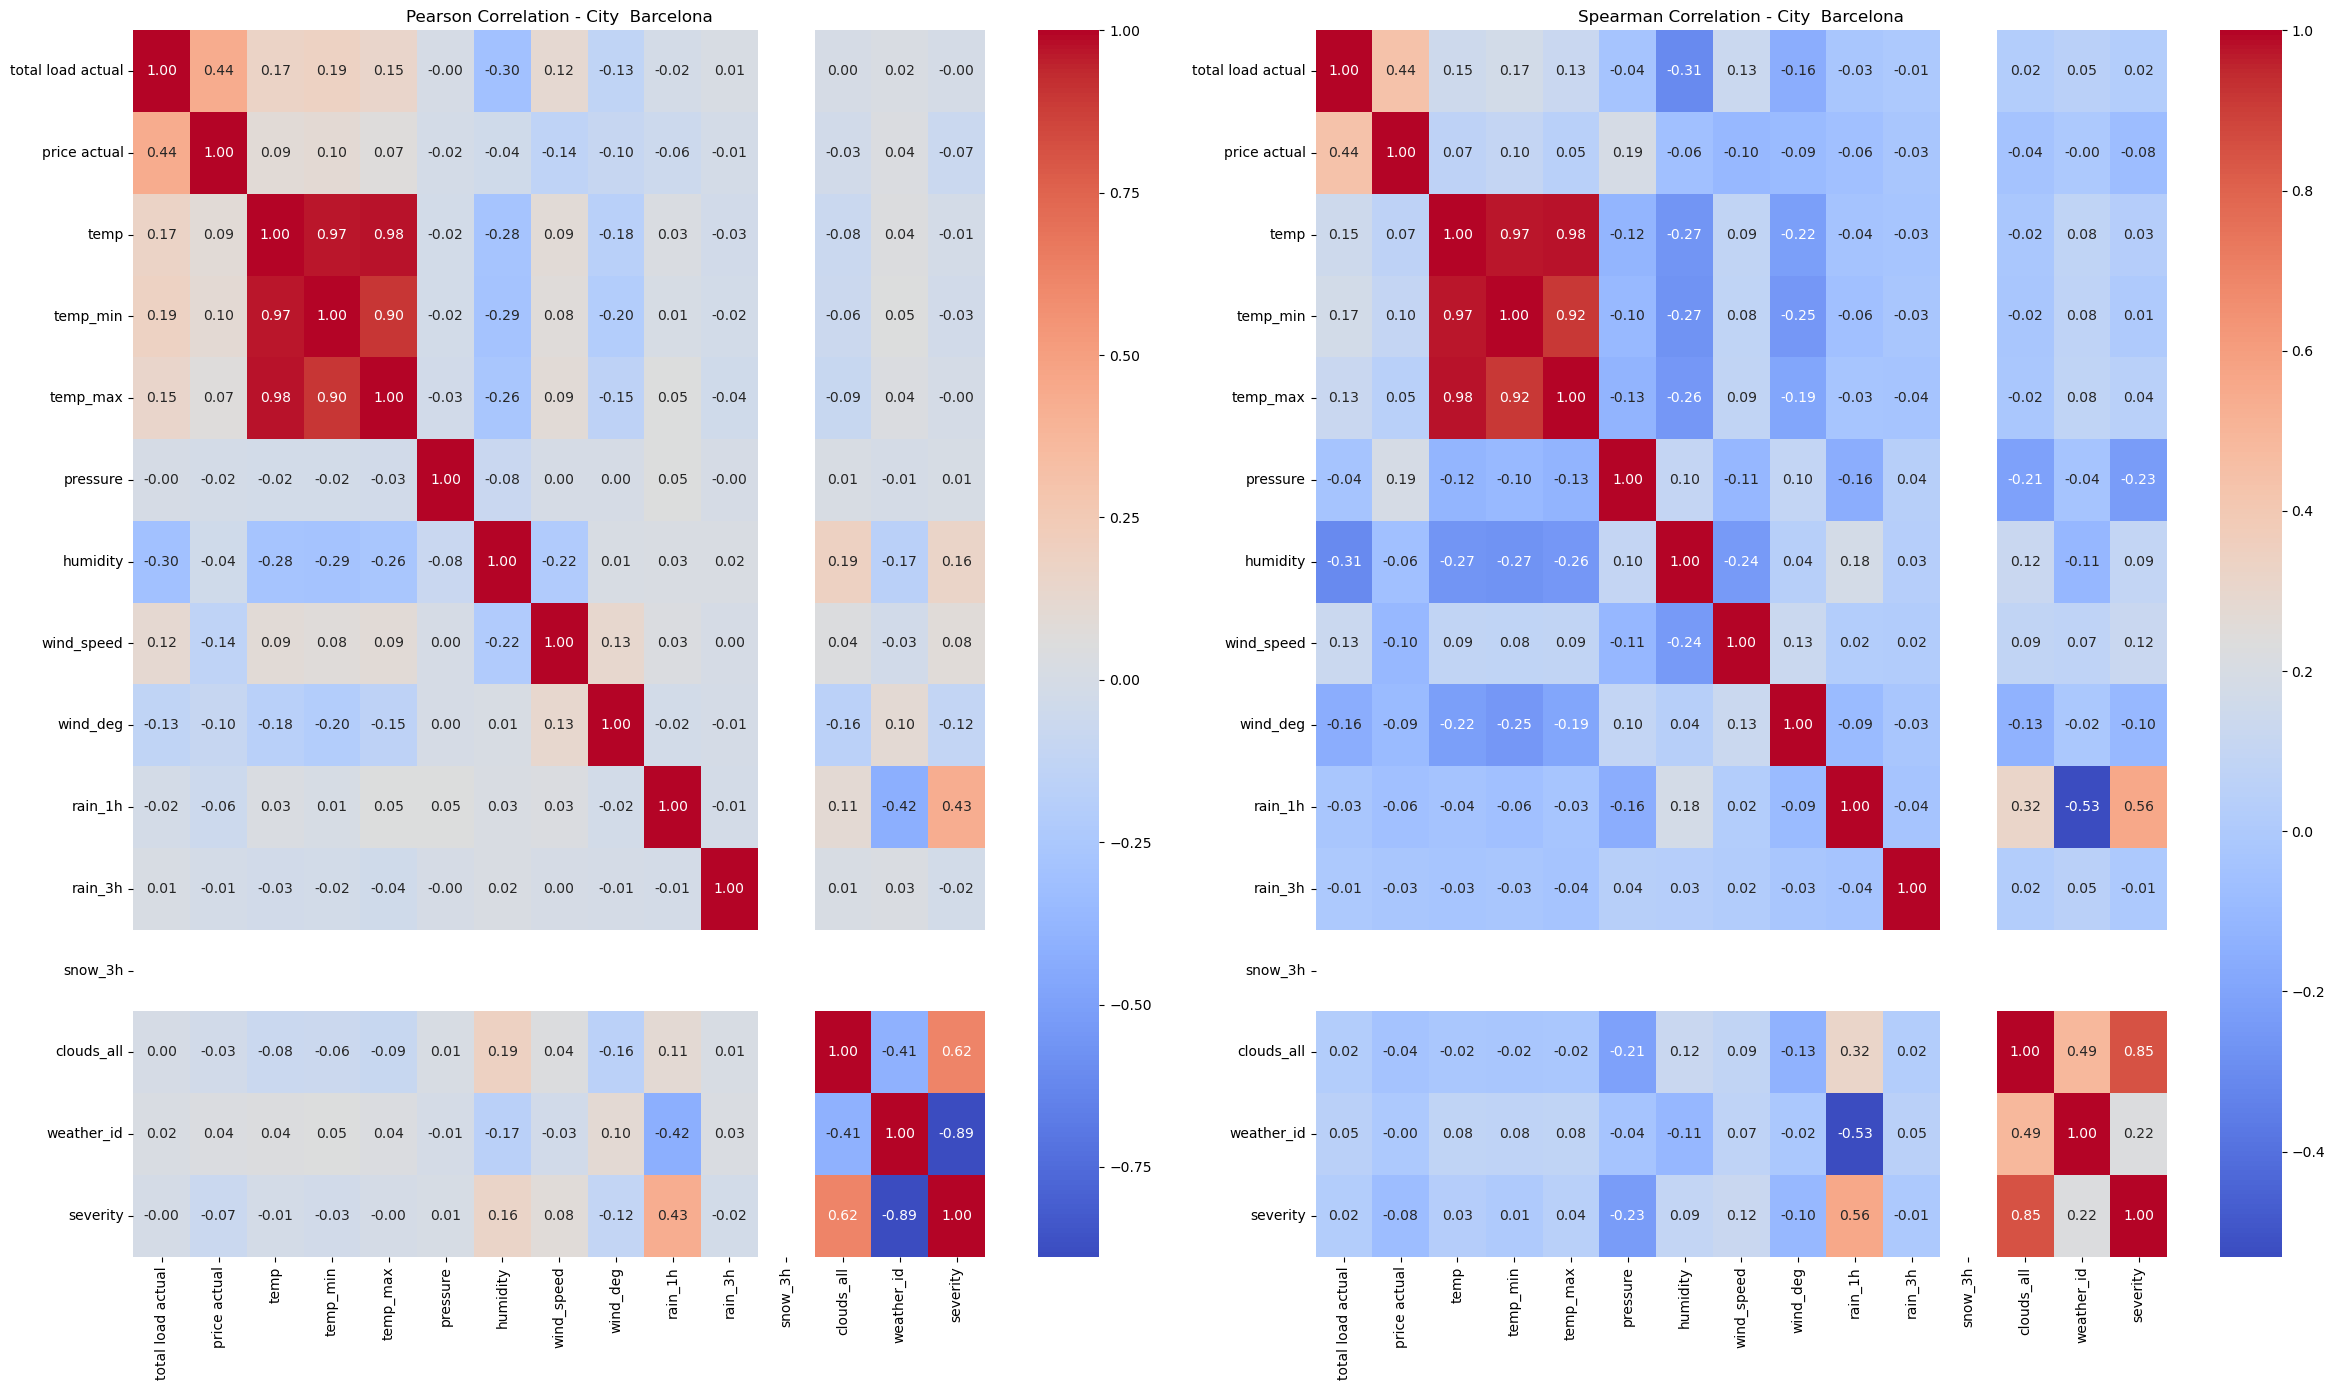

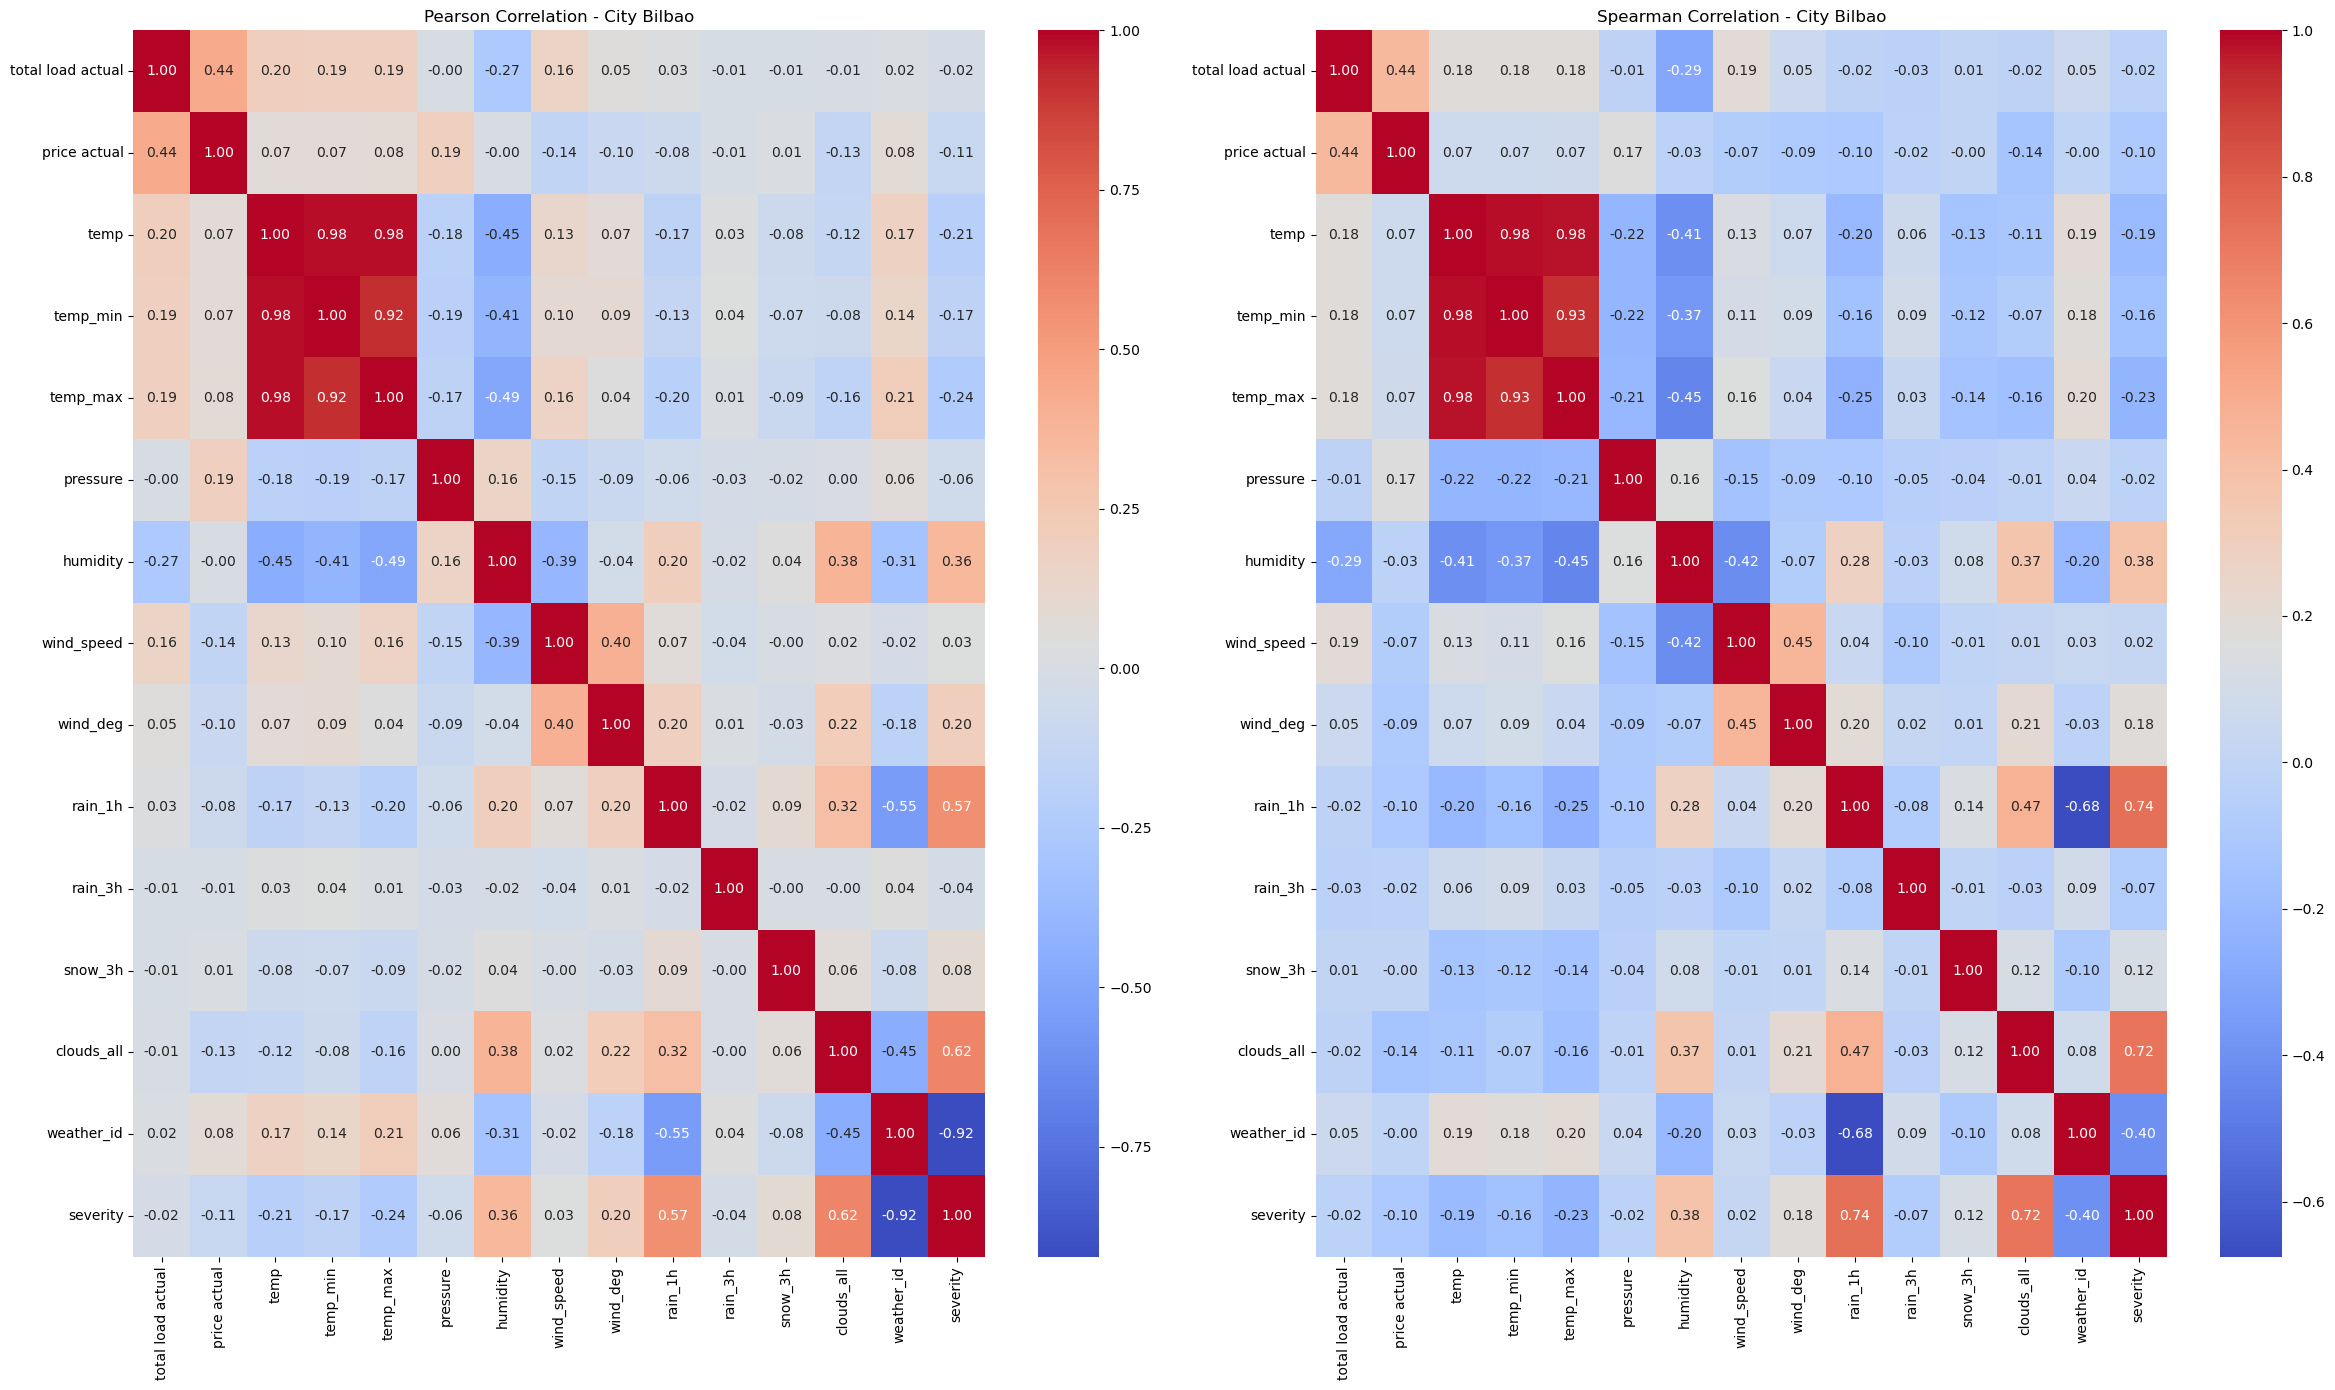

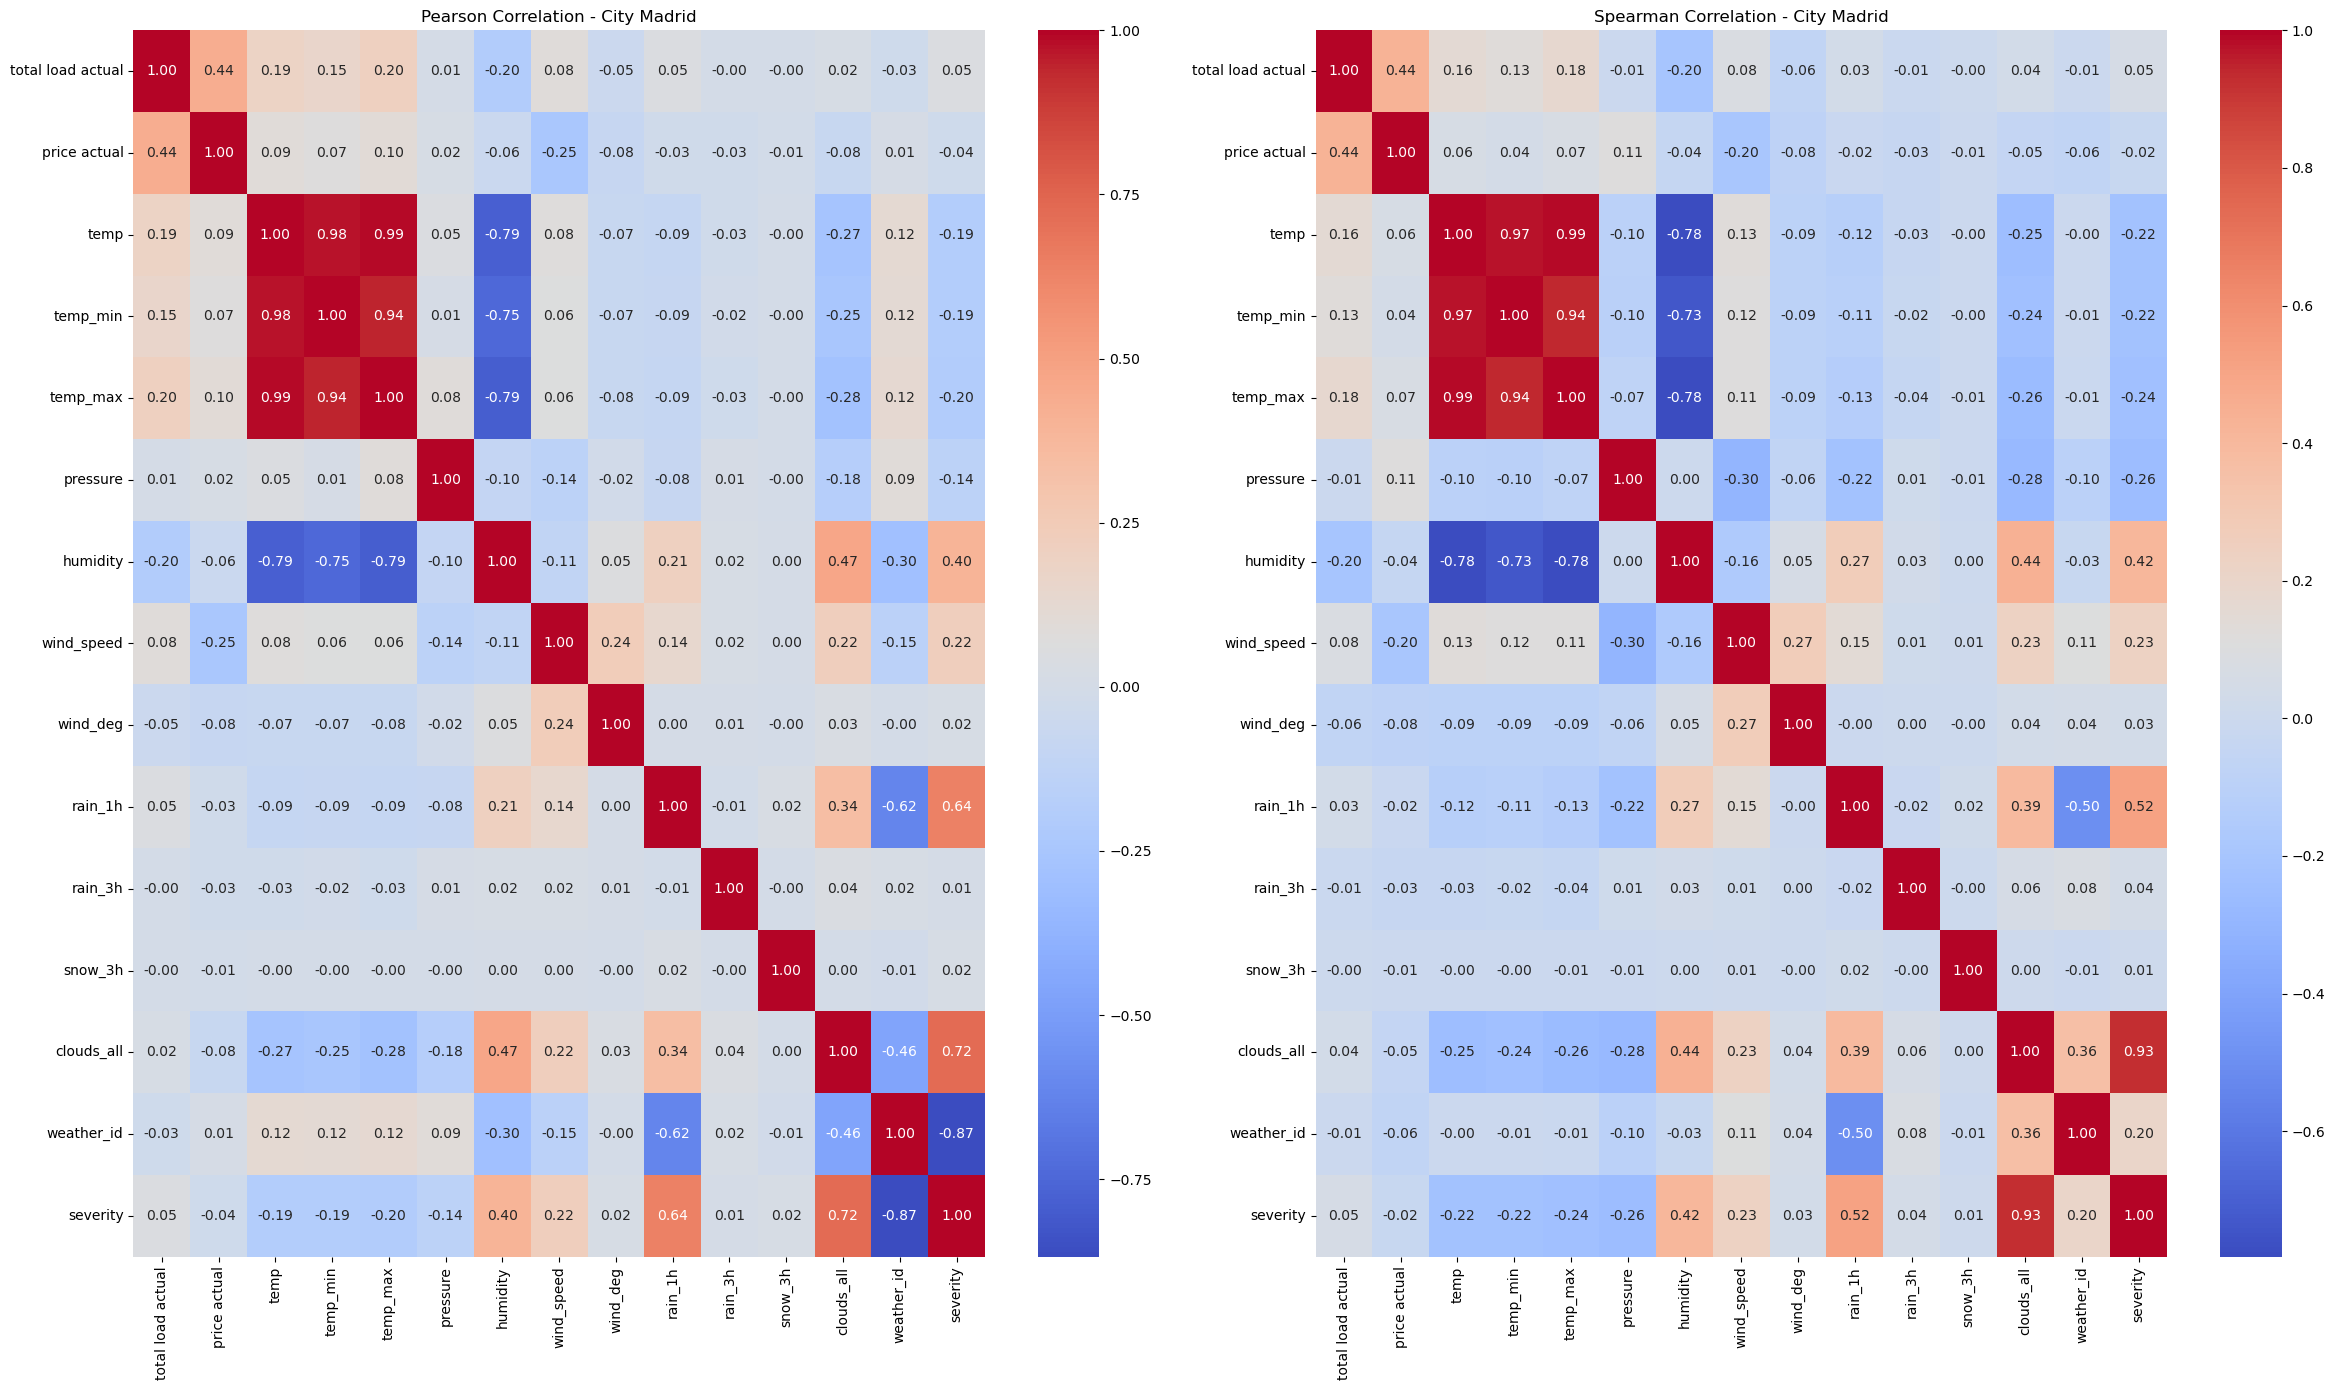

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/579591408.py:46: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, p = spearmanr(subset[col1], subset[col2])


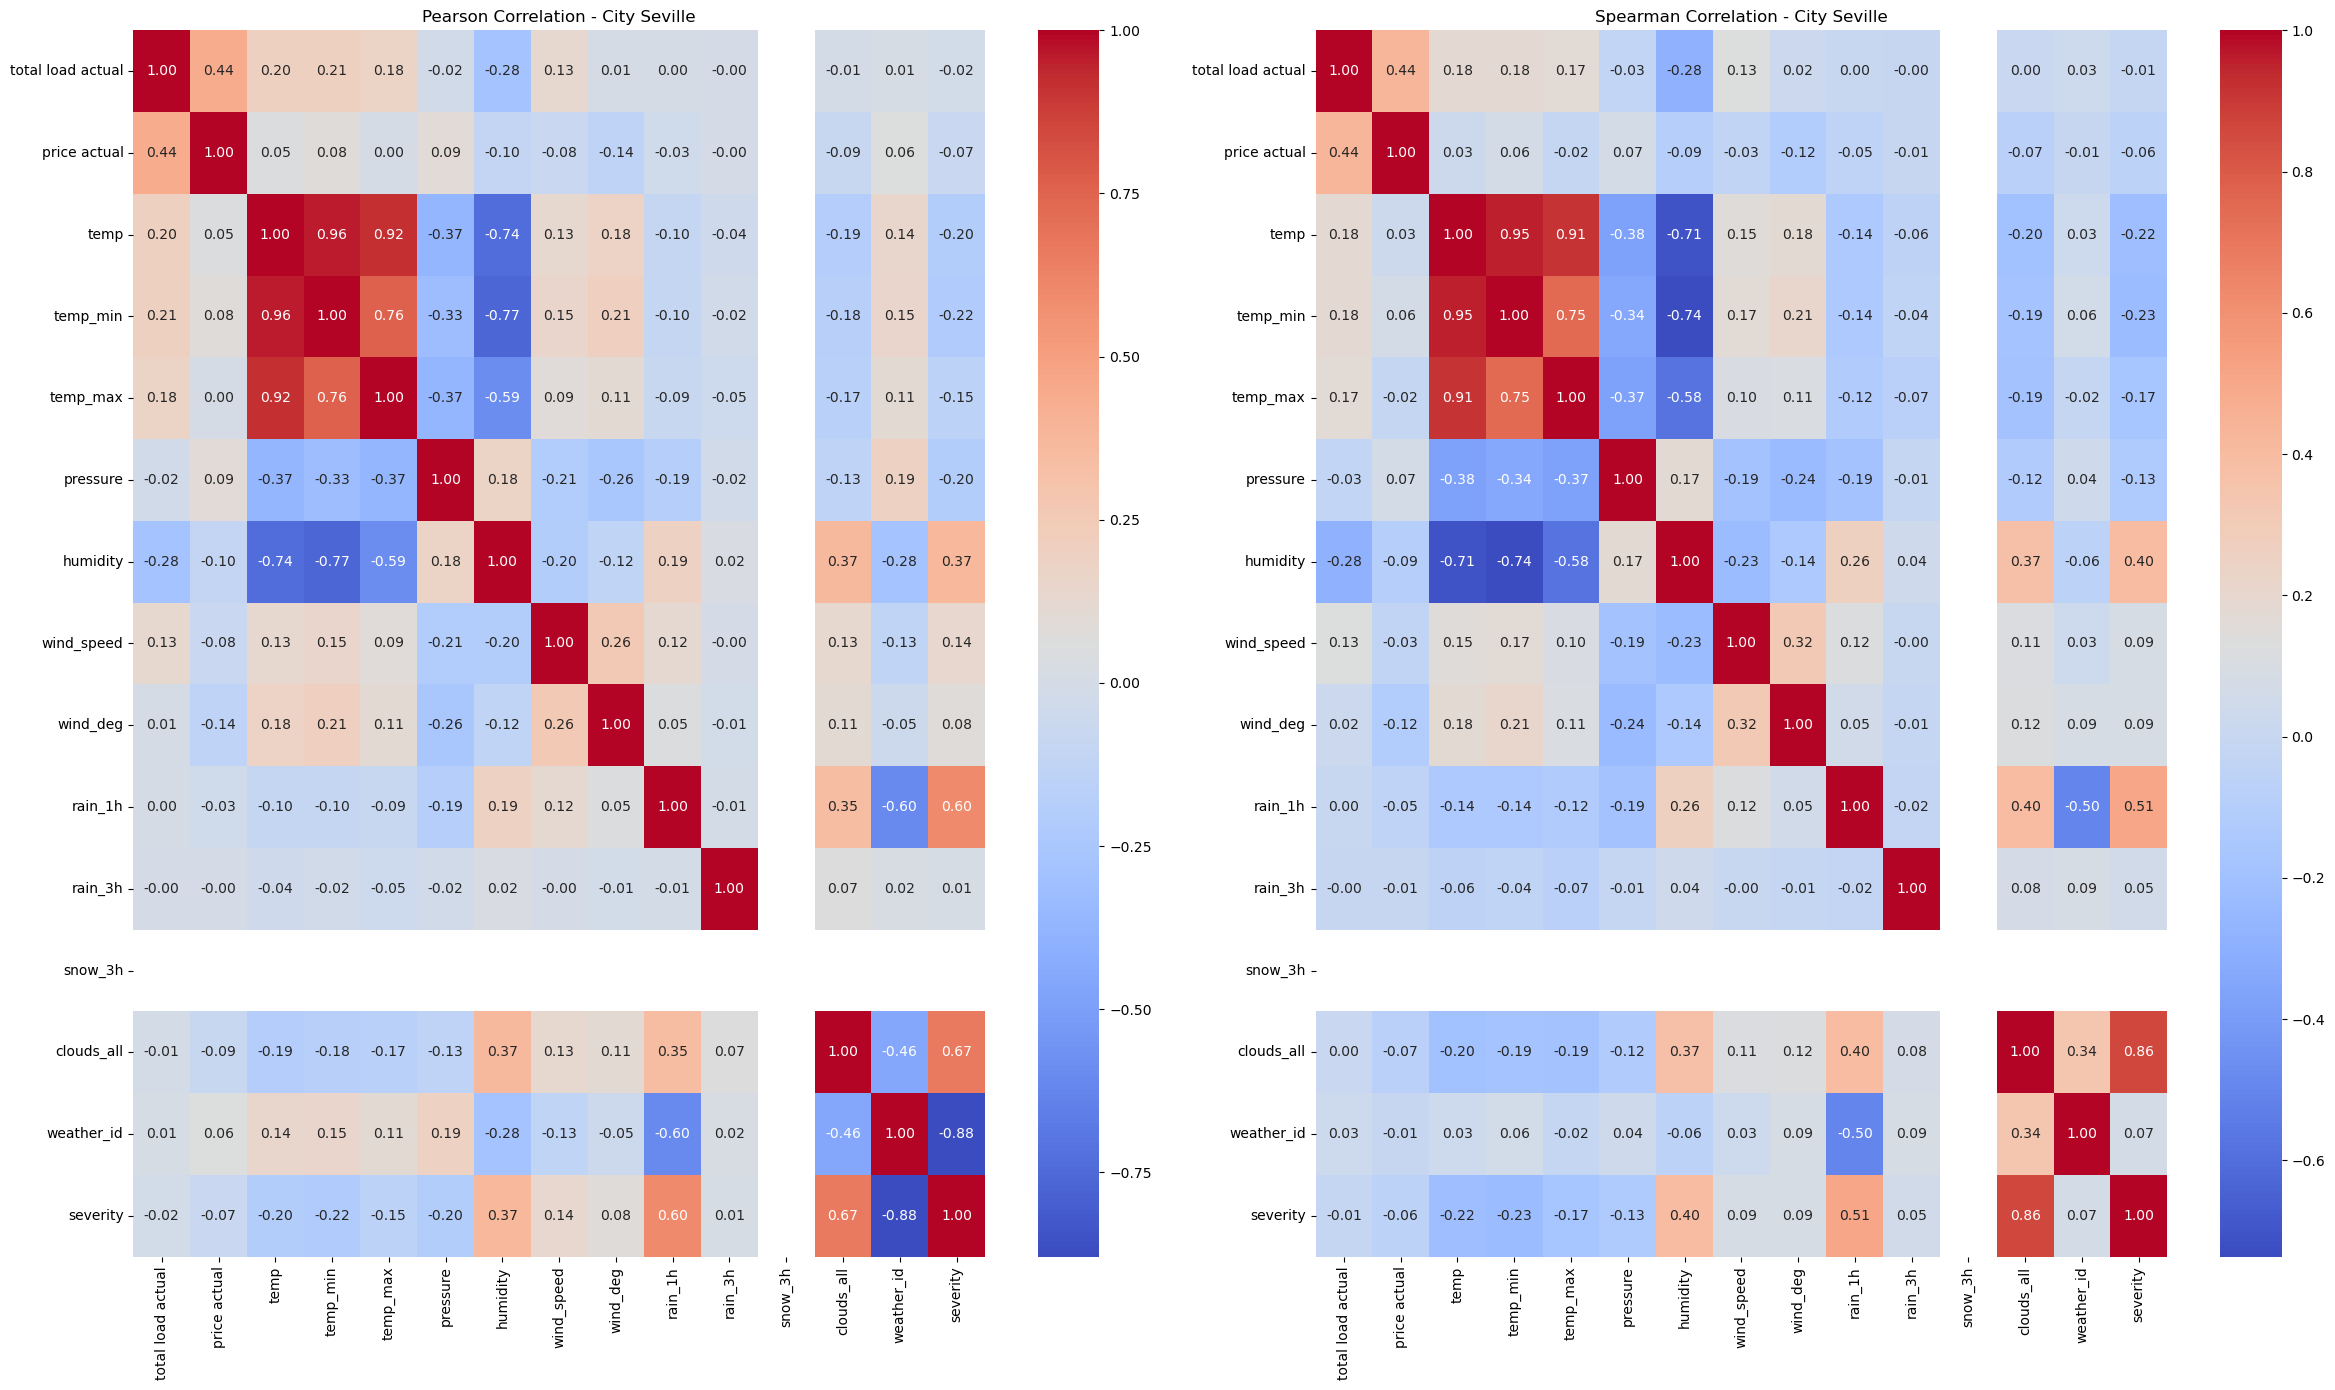

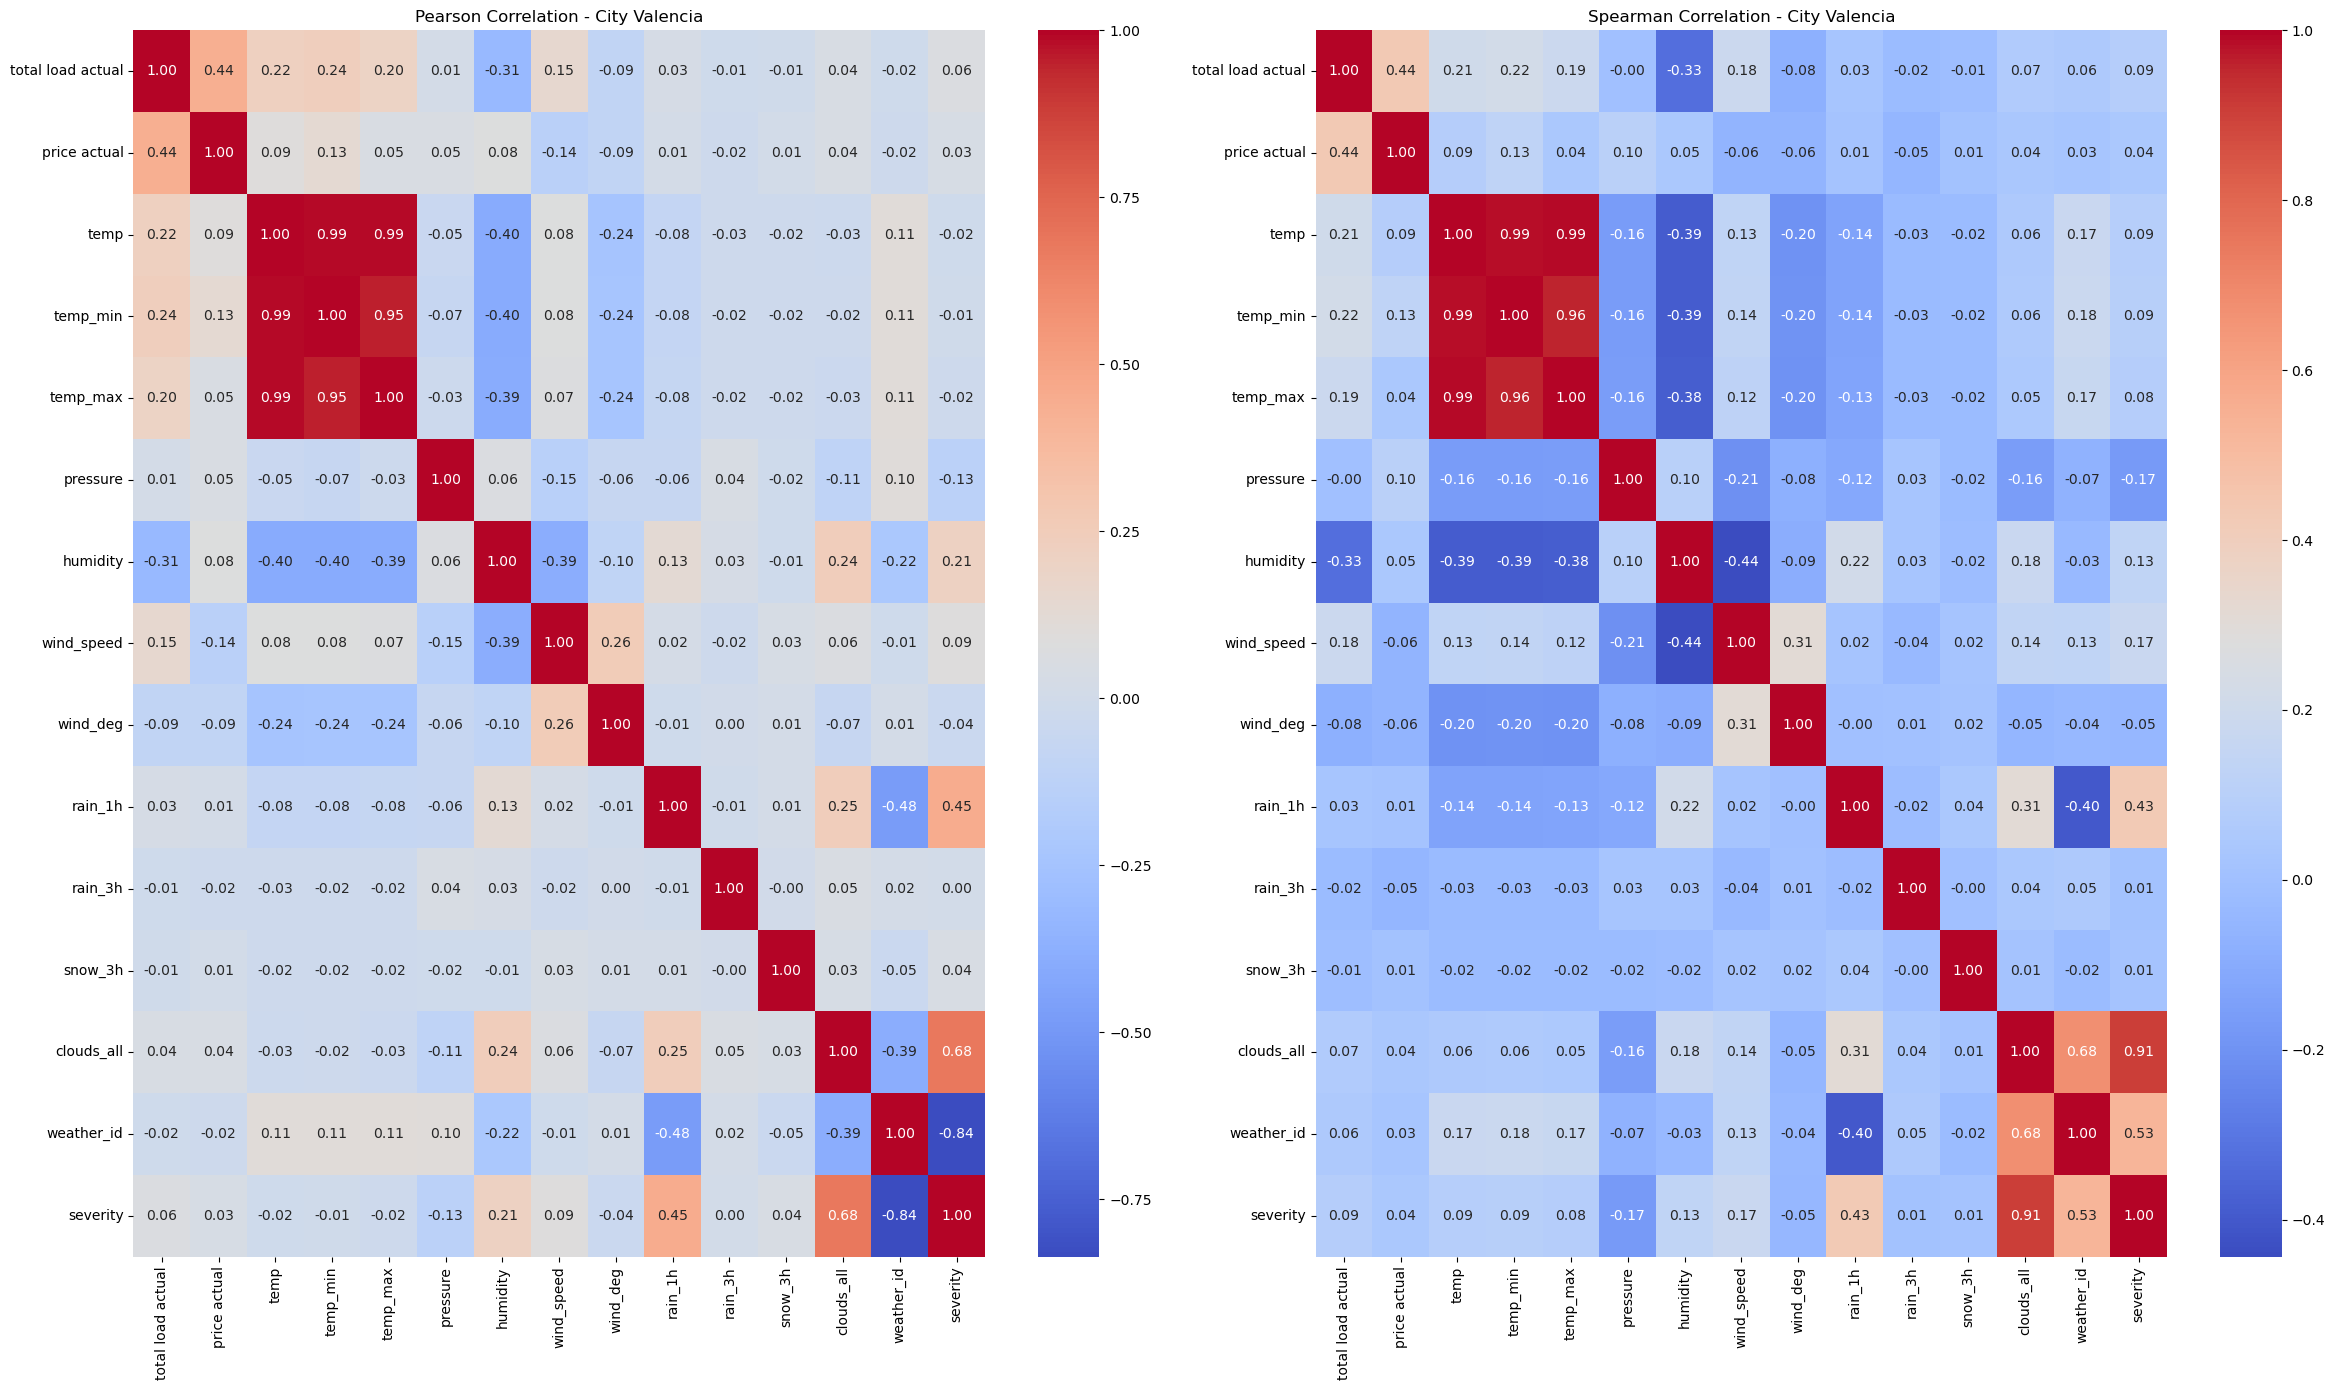

In [15]:
# Create Pearson and Spearman correlation heatmap matrices

# Import the spearman correlation function from the Scipy stats library.
from scipy.stats import spearmanr

# Need to specify the specifc power (usage and generation) and weather-related features. Let's look at renewable specifically,
# solar, wind, and other renewable along with load and price.
# power_load_price_features = ['generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas',
#                              'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption',
#                              'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear',
#                              'generation other', 'generation other renewable', 'generation solar', 'generation waste',
#                              'generation wind onshore', 'total load actual', 'price actual']

power_load_price_features = ['total load actual', 'price actual']

time_weather_other_features = ['temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
                               'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'weather_id', 'severity']

# Make a deep copy of the dataframe in case of accidental modifications
merged_power_weather_copy = merged_power_weather.copy(deep=True)

# The unique cities in the dataset.
cities = merged_power_weather_copy['city_name'].unique()

correlation_results = {}

for city in cities:
    subset = merged_power_weather_copy[merged_power_weather_copy['city_name'] == city]

    # Use only numeric weather/time columns + power columns
    features = power_load_price_features + time_weather_other_features
    
    subset = subset[features].dropna()
    if subset.empty:
        print(f"Skipping city {city} due to insufficient data.")
        continue

    pearson_corr = subset.corr(method='pearson')
    spearman_corr = subset.corr(method='spearman')

    # Compute Spearman p-values
    p_values = np.zeros((len(features), len(features)))
    for i, col1 in enumerate(features):
        for j, col2 in enumerate(features):
            if i != j:
                _, p = spearmanr(subset[col1], subset[col2])
                p_values[i, j] = p

    p_values_df = pd.DataFrame(p_values, index=features, columns=features)
    
    correlation_results[city] = {'pearson': pearson_corr, 'spearman': spearman_corr, 'p_values': p_values_df}

    # Plot heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(24, 14))
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
    axes[0].set_title(f'Pearson Correlation - City {city}')
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
    axes[1].set_title(f'Spearman Correlation - City {city}')

    direct_out = current_dir + '/output/exploratory/correlations/'
    if not os.path.exists(direct_out):
        os.makedirs(direct_out)
    filename_out = os.path.join(direct_out, f'Pearson_Spearman_heatmap_matrices_city_{city}_load_price.pdf')
    plt.tight_layout()
    plt.savefig(filename_out)
    plt.show()
    plt.close()

# Store and display Spearman correlation results for further inspection
correlation_data = pd.concat({k: v['spearman'] for k, v in correlation_results.items()}, names=['City'])

/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/1169187233.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  {pf: [spearmanr(subset[pf], subset[wf]).pvalue for wf in time_weather_other_features]


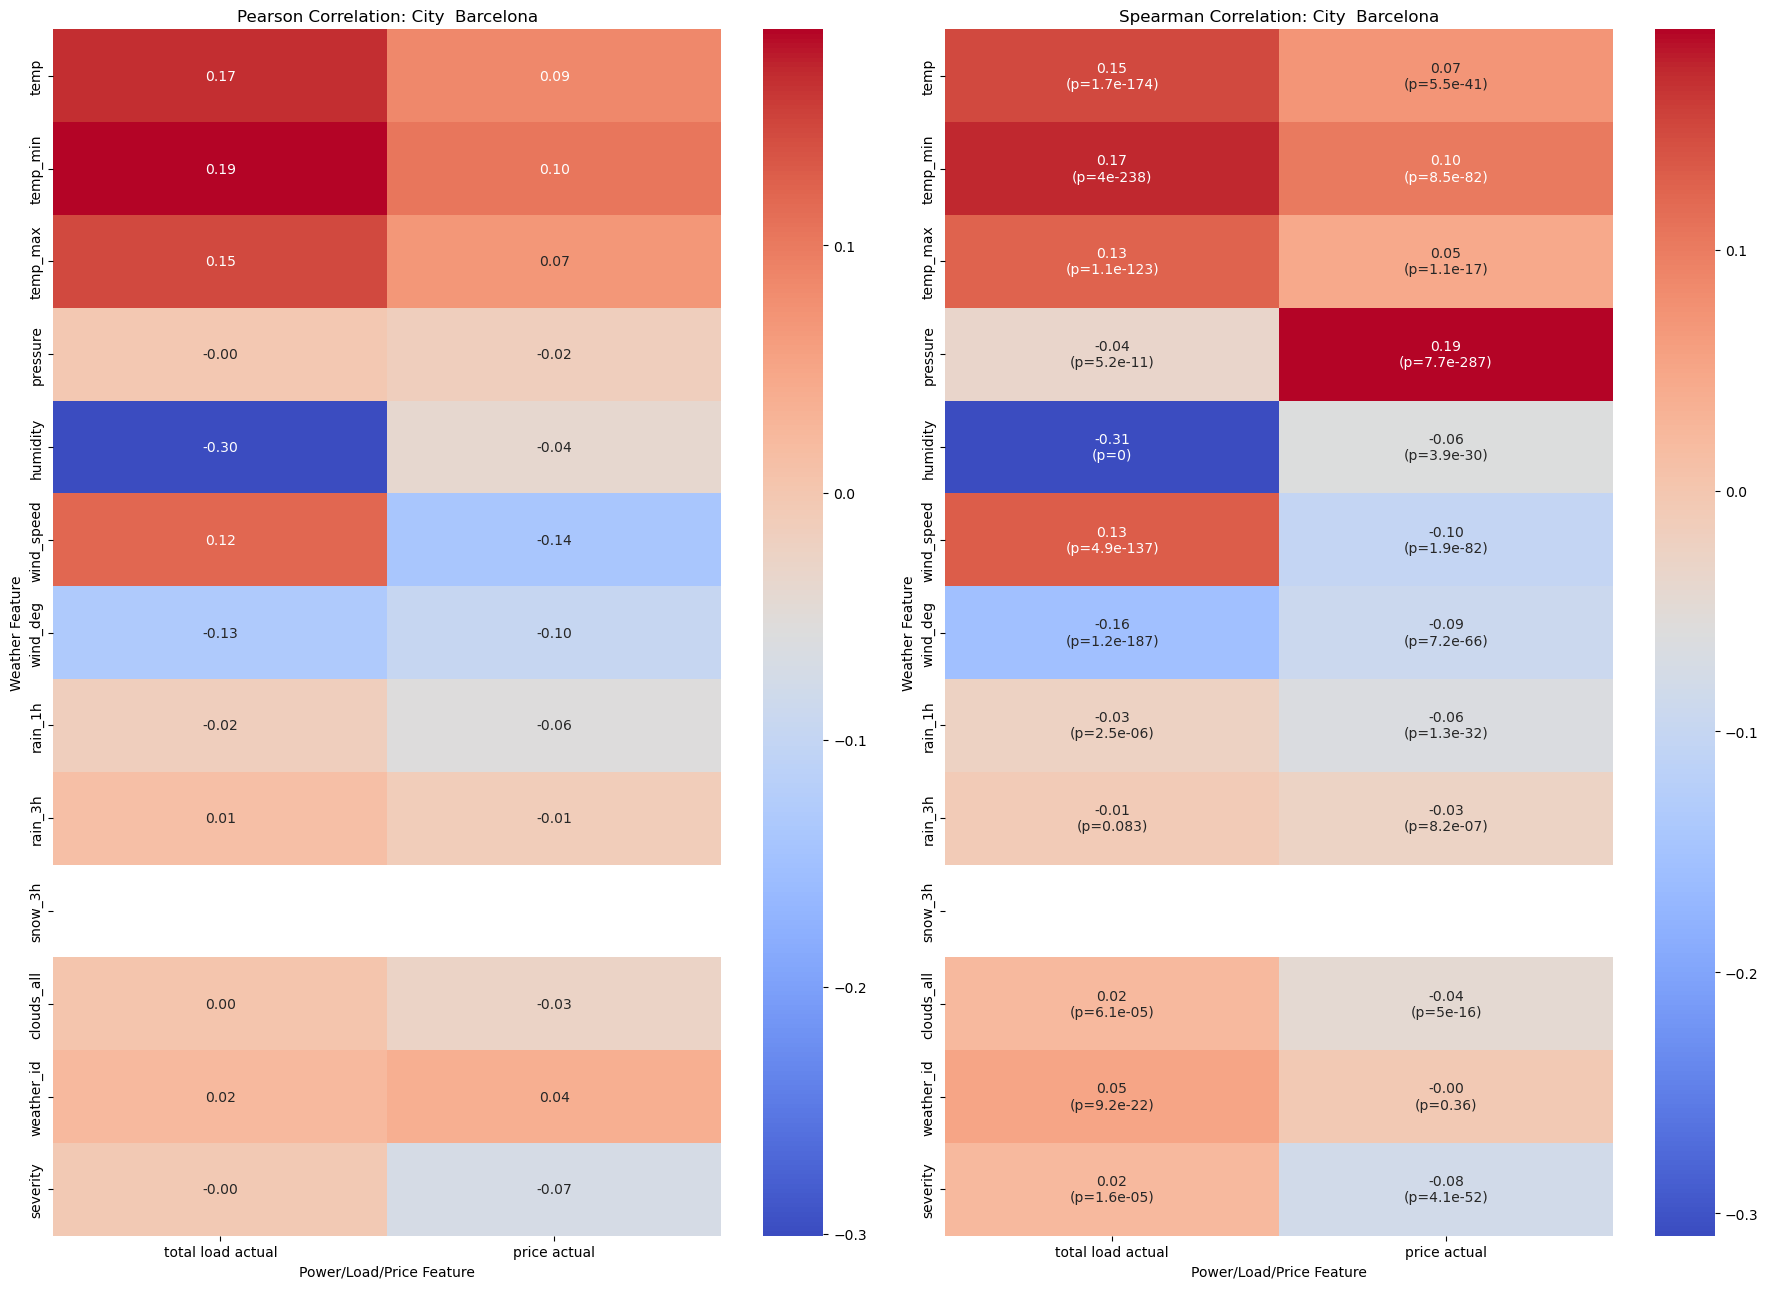

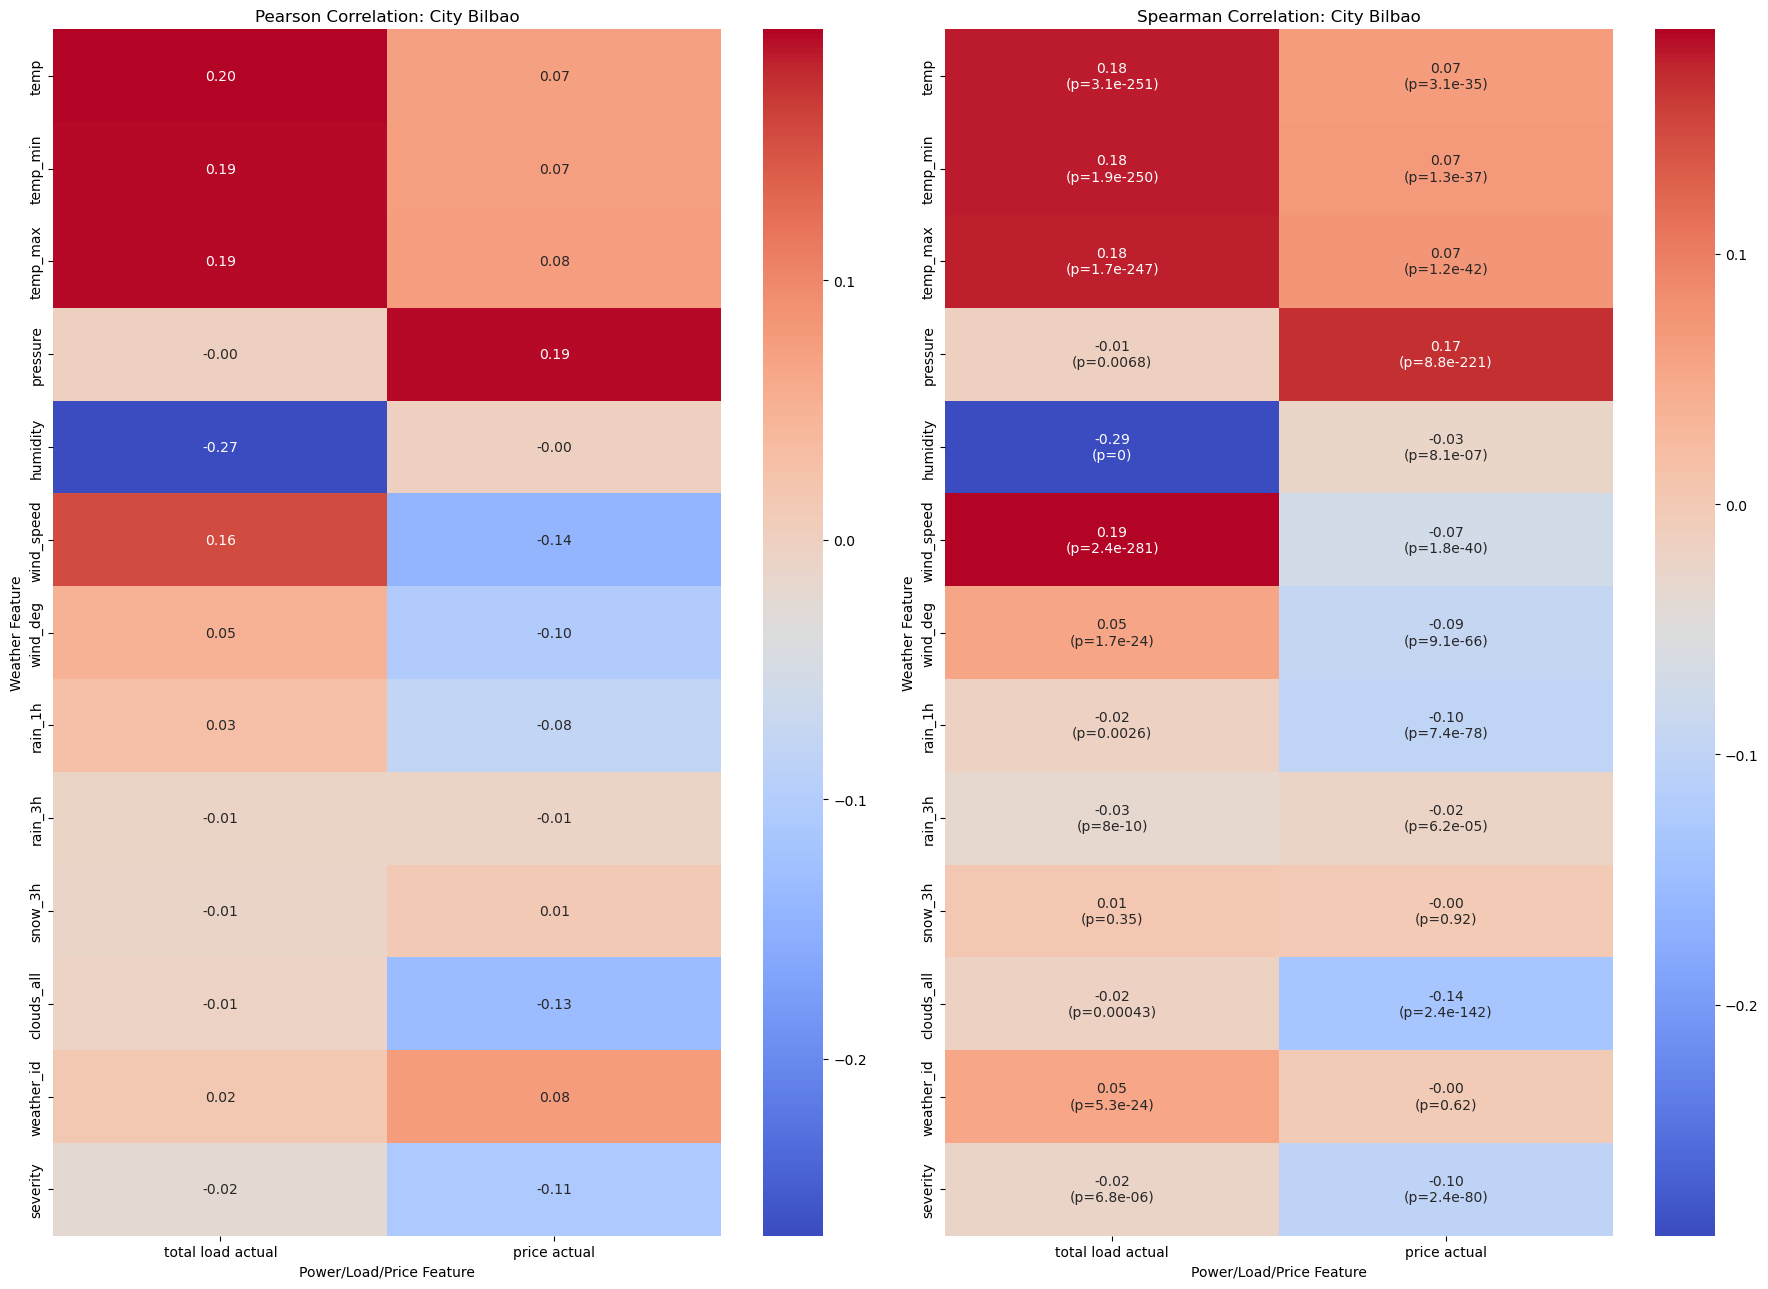

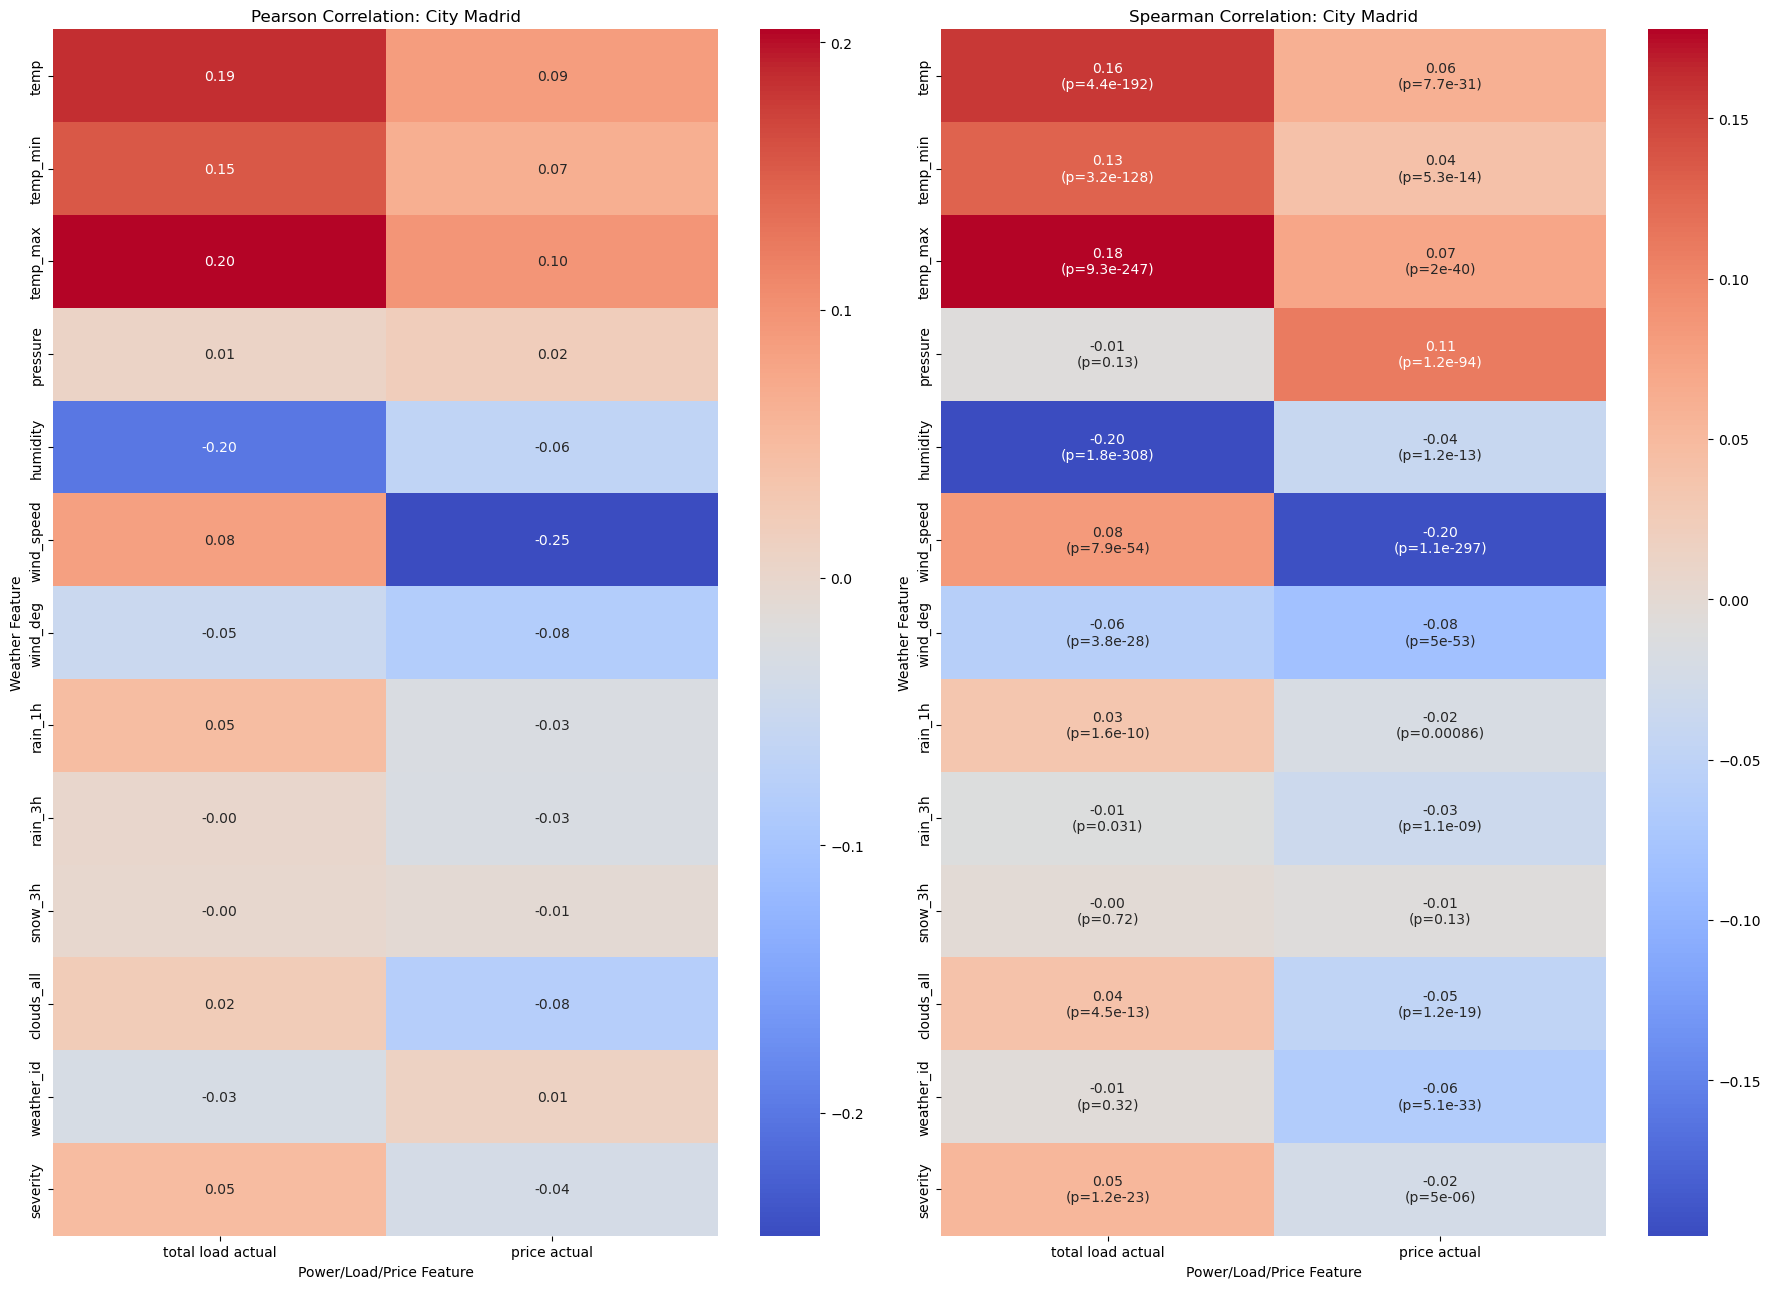

/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/1169187233.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  {pf: [spearmanr(subset[pf], subset[wf]).pvalue for wf in time_weather_other_features]


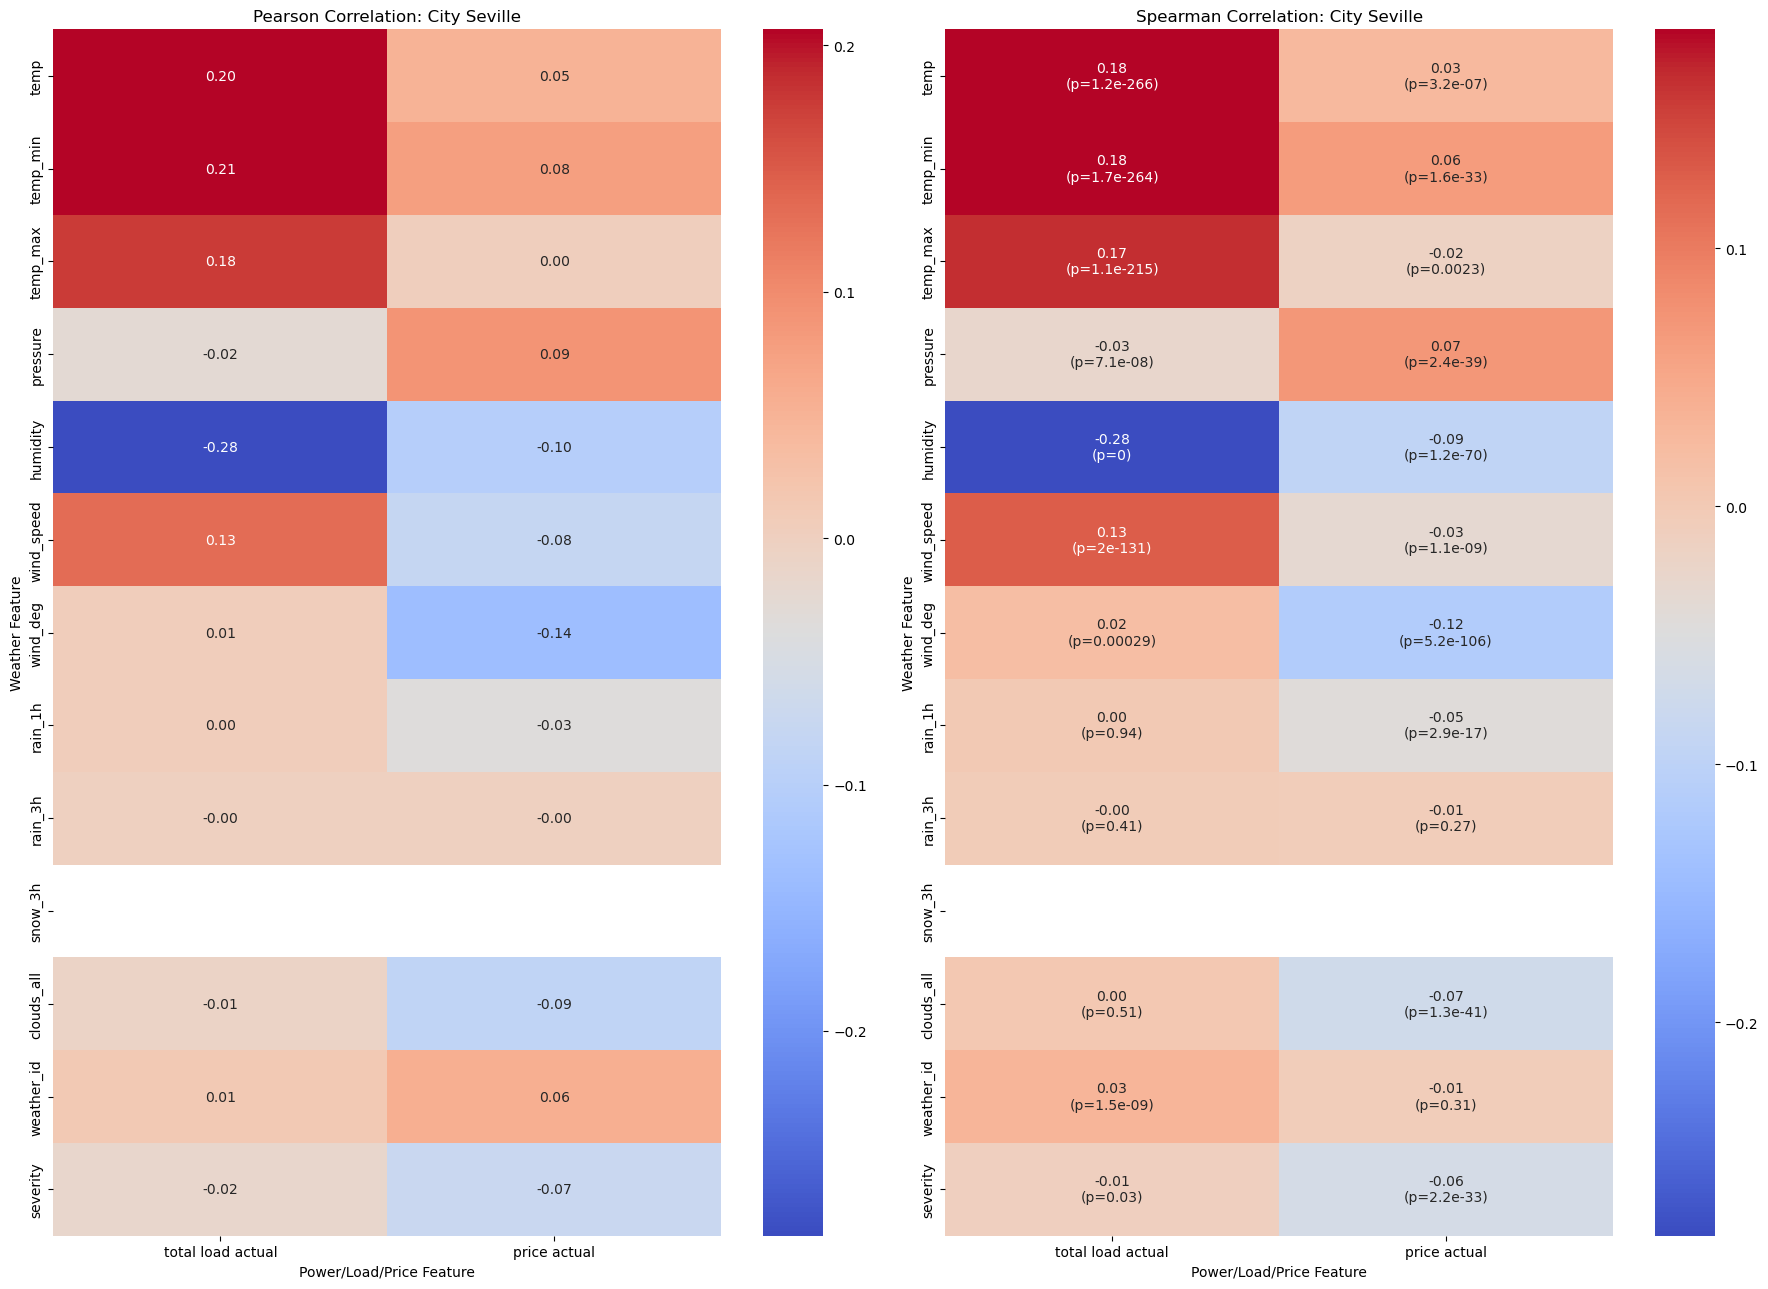

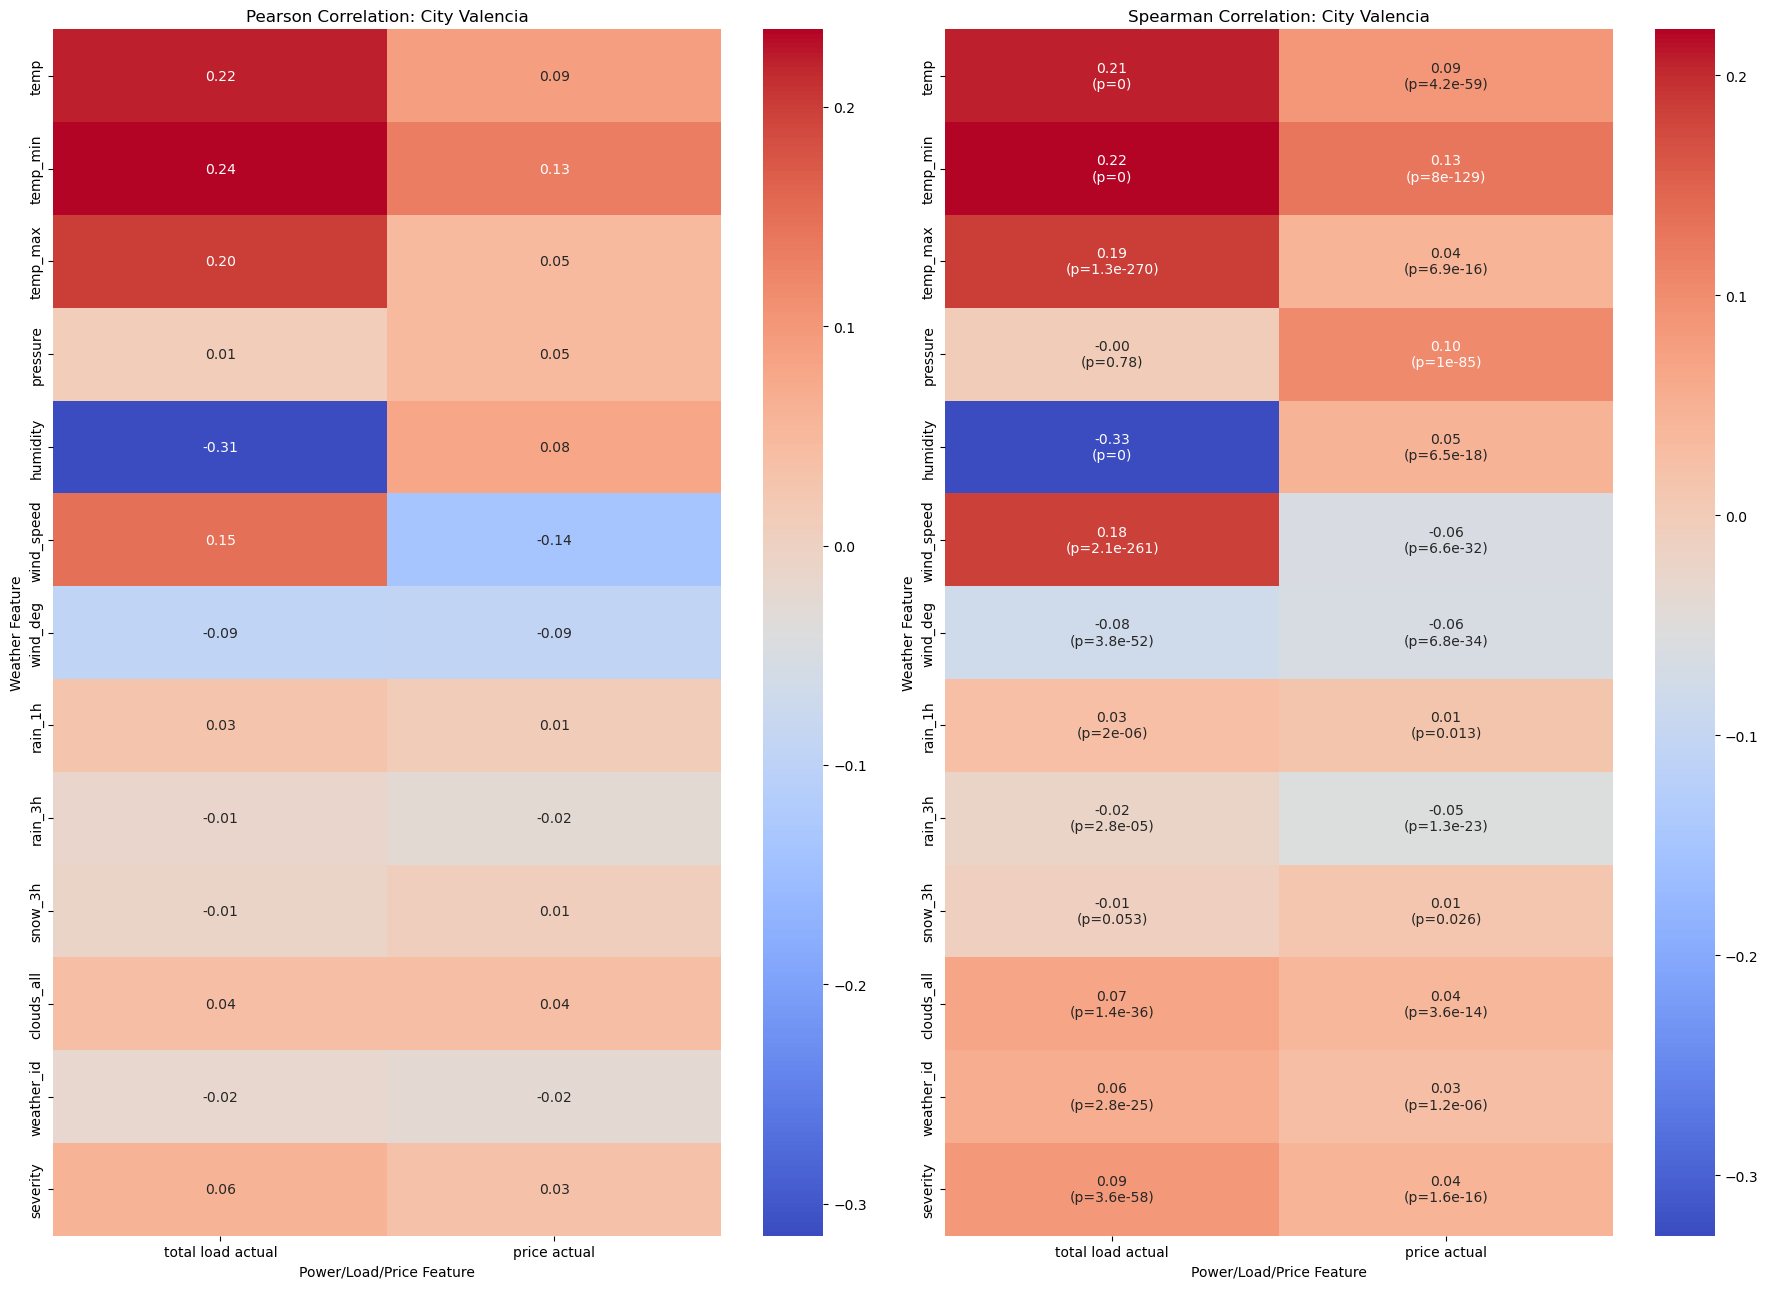

In [26]:
# Do the same things as above but as 1D heatmaps, showing the correlations between the weather features (in the rows) and
# power/load/price as columns.

from scipy.stats import spearmanr

# Define your selected features
power_load_price_features = ['total load actual', 'price actual']

time_weather_other_features = ['temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
                               'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'weather_id', 'severity']

merged_power_weather_copy = merged_power_weather.copy(deep=True)
cities = merged_power_weather_copy['city_name'].unique()

correlation_results = {}

for city in cities:
    subset = merged_power_weather_copy[merged_power_weather_copy['city_name'] == city]
    subset = subset[power_load_price_features + time_weather_other_features].dropna()

    if subset.empty:
        print(f"Skipping city {city} due to insufficient data.")
        continue

    # 2D matrix: weather rows × power columns
    pearson_corr = pd.DataFrame(
        {pf: [subset[pf].corr(subset[wf], method='pearson') for wf in time_weather_other_features]
         for pf in power_load_price_features},
        index=time_weather_other_features
    )

    spearman_corr = pd.DataFrame(
        {pf: [subset[pf].corr(subset[wf], method='spearman') for wf in time_weather_other_features]
         for pf in power_load_price_features},
        index=time_weather_other_features
    )

    # Compute p-values for Spearman
    spearman_pvals = pd.DataFrame(
        {pf: [spearmanr(subset[pf], subset[wf]).pvalue for wf in time_weather_other_features]
         for pf in power_load_price_features},
        index=time_weather_other_features
    )

    correlation_results[city] = {
        'pearson': pearson_corr,
        'spearman': spearman_corr,
        'spearman_pvals': spearman_pvals
    }

    # Plot Pearson and Spearman heatmaps side by side
    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(time_weather_other_features))))
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
    axes[0].set_title(f'Pearson Correlation: City {city}')
    axes[0].set_ylabel('Weather Feature')
    axes[0].set_xlabel('Power/Load/Price Feature')

    # For Spearman: add p-values in parentheses if you want
    spearman_annot = spearman_corr.copy().astype(str)
    for pf in power_load_price_features:
        for wf in time_weather_other_features:
            val = spearman_corr.loc[wf, pf]
            pval = spearman_pvals.loc[wf, pf]
            spearman_annot.loc[wf, pf] = f"{val:.2f}\n(p={pval:.2g})"

    sns.heatmap(spearman_corr, annot=spearman_annot, fmt="", cmap='coolwarm', ax=axes[1])
    axes[1].set_title(f'Spearman Correlation: City {city}')
    axes[1].set_ylabel('Weather Feature')
    axes[1].set_xlabel('Power/Load/Price Feature')

    plt.tight_layout()
    
    direct_out = current_dir + '/output/exploratory/correlations/'
    if not os.path.exists(direct_out):
        os.makedirs(direct_out)
    filename_out = os.path.join(direct_out, f'Pearson_Spearman_1D_heatmap_city_{city}_load_price.pdf')
    plt.savefig(filename_out)
    plt.show()
    plt.close()

# Store and display correlation results in a table format
correlation_data2 = pd.concat({k: v['spearman'] for k, v in correlation_results.items()}, names=['City'])

In [16]:
# Now I'll create a function to compute the solar irradiance as a function of local time and city.
import pvlib
from pvlib.location import Location
import pgeocode

def calculate_solar_flux(row):
    location = pvlib_locs[row['city_name']]
    # Get the position of the Sun, specifically the zenith elevation.
    solpos = location.get_solarposition(row['utc_time'])
    # Get the day of the year which is used for calculating Sun's position.
    day_of_year = row['local_time'].dayofyear
    # Use 1361Wm^2  as the solar radiation 'constant'.
    dni = pvlib.irradiance.disc(1361.0, solpos['zenith'], day_of_year)['dni']
    return dni.item()     # Convert single element numpy array to float when returning

In [17]:
merged_power_weather_feat = merged_power_weather.copy(deep=True)

# tqdm progress bar for pandas operations.
tqdm.pandas()

# Precompute city coordinate and put in dictionary.
city_names = merged_power_weather_feat['city_name'].unique()
nomi = pgeocode.Nominatim('ES')
city_coords = {}

for city in city_names:
    result = nomi.query_location(city)
    # Take the first row (if Series, convert; if DataFrame, take .iloc[0])
    if hasattr(result, 'iloc'):
        lat = float(result.iloc[0]['latitude'])
        lon = float(result.iloc[0]['longitude'])
    else:  # If already Series
        lat = float(result['latitude'])
        lon = float(result['longitude'])
    city_coords[city] = (lat, lon)

pvlib_locs = {city: Location(lat, lon) for city, (lat, lon) in city_coords.items()}

In [18]:
# Calculate the solar flux using pvlib and pgeocode by calling the calculate_solar_flux function I created in the previous cell.
# Instead of the normal .apply Pandas operation, I'll using progress_apply as the following takes some time (about 30 minutes).
merged_power_weather_feat['solar_flux_Wm2'] = merged_power_weather_feat.progress_apply(calculate_solar_flux, axis=1)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 175320/175320 [20:02<00:00, 145.82it/s]


In [32]:
# Plot solar generation and solar flux as weather feature
p = explore_plots(merged_power_weather_feat, 'local_time', ['total load actual'],
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Load\ (MWh)}$$",
                  'Power Load vs Local Time and Solar Flux', feature_columns=['solar_flux_Wm2'],
                  features_ylabel=[r"$$\mathrm{Solar\ Flux\ (W\ m^{-2})}$$"], p=None, normalize=False, other_colors=False,
                  color_plot=['dorange', 'dorange', 'dorange', 'dorange', 'dorange'],
                  color_features=['yellow', 'yellow', 'yellow', 'yellow', 'yellow'],
                  labels=['Power Load'], features_labels=['Solar Flux'],
                  symbols=['star', 'triangle', 'diamond', 'square', 'circle'],
                  symbols_features=['star', 'triangle', 'diamond', 'square', 'circle'],
                  replaced_columns=False)

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Power_load_vs_solar_flux2.html'

title = 'Power Load vs Local Time and Solar Flux'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/3089508979.py:26: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Power_load_vs_solar_flux2.html'

In [19]:
# Let's add the additional time/date features.
import holidays
from suntime import Sun
from datetime import date, datetime, timezone

# Compute the meteorological season based on month
def get_season(month):
    if month in [3, 4, 5]:
        # Spring
        return 1
    elif month in [6, 7, 8]:
        # Summer
        return 2
    elif month in [9, 10, 11]:
        # Autumn
        return 3
    else:
        # Winter
        return 0

# Determine the sunrise and sunset times.
def precompute_sunrise_sunset(city_coords_dict, all_dates):
    records = []
    for city, (lat, lon) in city_coords_dict.items():
        sun = Sun(lat, lon)
        for d in all_dates:
            # Make sure d is a datetime.date object (not pd.Timestamp)
            if isinstance(d, pd.Timestamp):
                d_py = d.date()
            else:
                d_py = d
            dt = datetime.combine(d_py, datetime.min.time()).replace(tzinfo=timezone.utc)
            try:
                sunrise = sun.get_sunrise_time(dt)
                sunset = sun.get_sunset_time(dt)
            except Exception as e:
                print(f"Failed for {city} {d_py}: {e}")
                sunrise, sunset = pd.NaT, pd.NaT
            records.append({'city_name': city, 'date': d_py, 'sunrise_time_utc': sunrise, 'sunset_time_utc': sunset})
    return pd.DataFrame(records)

def add_time_features(df, city_coords_dict, sun_table=None):
    df = df.copy()

    df['date'] = df['utc_time'].dt.date
    df['month'] = df['utc_time'].dt.month

    # If no precomputed table is given, build it now:
    if sun_table is None:
        all_dates = df['date'].unique()
        sun_table = precompute_sunrise_sunset(city_coords_dict, all_dates)

    # Merge sun_table (on city and date) into main dataframe
    df = df.merge(sun_table, on=['city_name', 'date'], how='left')

    # Remove timezone info for naive datetime columns (removes +00:00)
    df['sunrise_time_utc_naive'] = df['sunrise_time_utc'].dt.tz_localize(None)
    df['sunset_time_utc_naive'] = df['sunset_time_utc'].dt.tz_localize(None)

    # Daylight length (in hours)
    df['daylight_length_hr'] = (df['sunset_time_utc_naive'] - df['sunrise_time_utc_naive']).dt.total_seconds() / 3600.0

    neg_mask = df['daylight_length_hr'] < 0
    df.loc[neg_mask, 'daylight_length_hr'] = df.loc[neg_mask, 'daylight_length_hr'] + 24.0

    df['sunrise_time_utc'] = df['sunrise_time_utc_naive'].dt.time
    df['sunset_time_utc'] = df['sunset_time_utc_naive'].dt.time

    # Sunrise/sunset as fractions of day (UTC)
    df['sunrise_day_fraction_utc'] = (
        df['sunrise_time_utc_naive'].dt.hour / 24 +
        df['sunrise_time_utc_naive'].dt.minute / (24*60) +
        df['sunrise_time_utc_naive'].dt.second / (24*3600)
    )
    df['sunset_day_fraction_utc'] = (
        df['sunset_time_utc_naive'].dt.hour / 24 +
        df['sunset_time_utc_naive'].dt.minute / (24*60) +
        df['sunset_time_utc_naive'].dt.second / (24*3600)
    )

    df = df.drop(columns=['sunrise_time_utc_naive', 'sunset_time_utc_naive'])

    # UTC time as fraction of day
    df['utc_time_day_fraction'] = df['utc_time'].dt.hour/24.0 + df['utc_time'].dt.minute/(24.0*60) + df['utc_time'].dt.second/(24.0*3600)
    # Date as fraction of year
    df['day_of_year'] = df['utc_time'].dt.dayofyear
    df['date_fraction_of_year'] = df['day_of_year'] / 365.25

    # Day of week (Monday=0)
    df['day_of_week'] = df['utc_time'].dt.dayofweek
    # # Is weekend (0 for Mon–Fri, 1 for Sat/Sun)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Cyclical time encodings
    df['day_hour_sin'] = np.sin(2 * np.pi * df['utc_time'].dt.hour / 24)
    df['day_hour_cos'] = np.cos(2 * np.pi * df['utc_time'].dt.hour / 24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['season'] = df['month'].apply(get_season)

    years = df['local_time'].dt.year.unique().tolist()
    es_holidays = holidays.country_holidays('ES', years=years)
    df['is_holiday'] = df['local_time'].dt.date.isin(es_holidays).astype(int)

    return df

In [20]:
merged_power_weather_feat2 = merged_power_weather_feat.copy(deep=True)

# Precompute sunrise/sunset for all unique dates and cities
all_dates = merged_power_weather_feat2['utc_time'].dt.date.unique()
sun_table = precompute_sunrise_sunset(city_coords, all_dates)

merged_power_weather_feat2 = add_time_features(merged_power_weather_feat2, city_coords, sun_table)
#merged_power_weather_feat2 = add_time_features(merged_power_weather_feat2, city_coords)

direct_out = current_dir + '/output'
filename_out = direct_out + '/power_weather_dataset_with_new_features.csv'
merged_power_weather_feat2.to_csv(filename_out, index=False)

In [21]:
merged_power_weather_feat_final = merged_power_weather_feat2.copy(deep=True)

# Weather columns to roll by city
weather_features = [
    'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
    'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'solar_flux_Wm2'
]

# Power features to roll (national)
power_features = [
    'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas',
    'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage', 'generation hydro water reservoir',
    'generation nuclear', 'generation other', 'generation other renewable', 'generation solar',
    'generation waste', 'generation wind onshore'
]

# Features to roll for both 3h and 6h (e.g., for load and price)
special_features = ['total load actual', 'price actual']

In [22]:
# WEATHER: by city_name and sorted by utc_time
merged_power_weather_feat_final = merged_power_weather_feat_final.sort_values(['city_name', 'utc_time'])
for col in weather_features:
    # Data leakage here, don't use.
    # merged_power_weather_feat_final[f'{col}_rolling3h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values(['city_name', 'utc_time'])
    #     .groupby('city_name')[col]
    #     .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final
        .groupby('city_name')[col]
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    )

    # Fill the first row of each city (where shift(1) makes it NaN) with the current value.
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[f'{col}_rolling3h']
        .fillna(merged_power_weather_feat_final[col])
    )

# POWER: National level (no city), sorted by utc_time
merged_power_weather_feat_final = merged_power_weather_feat_final.sort_values('utc_time')
for col in power_features:
    # Data leakage
    # merged_power_weather_feat_final[f'{col}_rolling3h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values('utc_time')[col]
    #     .rolling(window=3, min_periods=1)
    #     .mean()
    #     .values
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[col]
        .shift(1).rolling(window=3, min_periods=1)
        .mean()
    )

    # Fill the first row of with the current value.
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[f'{col}_rolling3h']
        .fillna(merged_power_weather_feat_final[col])
    )

# Special features (total load actual, price actual): 3h and 6h
for col in special_features:
    # Data leakage
    # merged_power_weather_feat_final[f'{col}_rolling3h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values('utc_time')[col]
    #     .rolling(window=3, min_periods=1)
    #     .mean()
    #     .values
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[col]
        .shift(1).rolling(window=3, min_periods=1)
        .mean()
    )

    # Fill the first row of with the current value.
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[f'{col}_rolling3h']
        .fillna(merged_power_weather_feat_final[col])
    )

    # Data leakage
    # merged_power_weather_feat_final[f'{col}_rolling6h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values('utc_time')[col]
    #     .rolling(window=6, min_periods=1)
    #     .mean()
    #     .values
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling6h'] = (
        merged_power_weather_feat_final[col]
        .shift(1).rolling(window=6, min_periods=1)
        .mean()
    )

    # Fill the first row of with the current value.
    merged_power_weather_feat_final[f'{col}_rolling6h'] = (
        merged_power_weather_feat_final[f'{col}_rolling6h']
        .fillna(merged_power_weather_feat_final[col])
    )

In [23]:
time_feature_columns = [
    'date', 'month', 'sunrise_time_utc', 'sunset_time_utc', 'daylight_length_hr', 'sunrise_day_fraction_utc',
    'sunset_day_fraction_utc', 'utc_time_day_fraction', 'day_of_year', 'date_fraction_of_year',
    'day_of_week', 'is_weekend', 'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos', 'season', 'is_holiday'
]

# Remove from current columns and re-insert at the right spot
cols = merged_power_weather_feat_final.columns.tolist()
# Remove time_feature_columns from their current positions
cols = [c for c in cols if c not in time_feature_columns]
# Insert after 'utc_time'
utc_time_idx = cols.index('utc_time')
for offset, c in enumerate(time_feature_columns):
    cols.insert(utc_time_idx + 1 + offset, c)

In [24]:
def insert_rolling_after_original(cols, df, rolling_suffixes=['_rolling3h', '_rolling6h']):
    new_cols = []
    already_added = set()
    for c in cols:
        new_cols.append(c)
        already_added.add(c)
        # Insert rolling variant(s) if present
        for sfx in rolling_suffixes:
            rc = c + sfx
            if rc in df.columns and rc not in already_added:
                new_cols.append(rc)
                already_added.add(rc)
    # Do not append remaining rolling columns again!
    return new_cols

# Rebuild cols to avoid duplication
cols = merged_power_weather_feat_final.columns.tolist()

# Remove the rolling columns from their current position (if present)
for col in merged_power_weather_feat_final.columns:
    if col.endswith('_rolling3h') or col.endswith('_rolling6h'):
        if col in cols:
            cols.remove(col)

# Insert rolling columns next to originals, without duplication
cols = insert_rolling_after_original(cols, merged_power_weather_feat_final)
merged_power_weather_feat_final = merged_power_weather_feat_final[cols]

In [25]:
# 1. Main time columns
main_time_cols = ['local_time', 'utc_time', 'utc_timestamp']

# 2. Time feature columns
time_feature_cols = [
    'date', 'month', 'sunrise_time_utc', 'sunset_time_utc', 'daylight_length_hr',
    'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'utc_time_day_fraction',
    'day_of_year', 'date_fraction_of_year', 'day_of_week', 'is_weekend', 'day_hour_sin',
    'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin',
    'day_of_year_cos', 'month_sin', 'month_cos', 'season', 'is_holiday'
]

# 3. City column
city_col = ['city_name']

# 4. The rest: everything except above (order: weather, power, forecasts, rolling, etc.)
exclude = set(main_time_cols + time_feature_cols + city_col)
rest_cols = [c for c in merged_power_weather_feat_final.columns if c not in exclude]

# To get rolling columns next to original, do this:
def get_original_and_rolling(cols):
    used = set()
    new_cols = []
    for col in cols:
        if col in used:
            continue
        new_cols.append(col)
        used.add(col)
        # Add matching rolling cols
        for suf in ['_rolling3h', '_rolling6h']:
            rolling_col = f"{col}{suf}"
            if rolling_col in cols and rolling_col not in used:
                new_cols.append(rolling_col)
                used.add(rolling_col)
    return new_cols

# Order weather and power columns with rolling features next to originals
weather_power_rolling_cols = [
    'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
    'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'solar_flux_Wm2', 'weather_id', 'weather_main',
    'weather_description', 'weather_icon', 'severity', 
    'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas',
    'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage', 'generation hydro water reservoir',
    'generation nuclear', 'generation other', 'generation other renewable',
    'generation solar', 'generation waste', 'generation wind onshore',
    'total load actual', 'price actual'
]

# Add rolling for weather/power columns
weather_power_rolling_cols_all = []
for col in weather_power_rolling_cols:
    weather_power_rolling_cols_all.append(col)
    if f"{col}_rolling3h" in merged_power_weather_feat_final.columns:
        weather_power_rolling_cols_all.append(f"{col}_rolling3h")
    if f"{col}_rolling6h" in merged_power_weather_feat_final.columns:
        weather_power_rolling_cols_all.append(f"{col}_rolling6h")

# Other columns (forecast, weather description, etc.) in their original order
leftover_cols = [c for c in rest_cols if c not in weather_power_rolling_cols_all]

# Final column order
final_order = (
    main_time_cols +
    time_feature_cols +
    city_col +
    weather_power_rolling_cols_all +
    leftover_cols
)

# Reorder the dataframe
merged_power_weather_feat_final = merged_power_weather_feat_final[final_order]

In [26]:
merged_power_weather_feat_final['city_name'] = merged_power_weather_feat_final['city_name'].str.strip()

city_populations_2016 = {
    'Madrid': 3238048,
    'Barcelona': 1619286,
    'Valencia': 790448,
    'Seville': 691191,
    'Bilbao': 348553
}

total_population = sum(city_populations_2016.values())
city_weights = {city: pop / total_population for city, pop in city_populations_2016.items()}

merged_power_weather_feat_final['city_weights'] = merged_power_weather_feat_final['city_name'].map(city_weights)

In [27]:
# I'll start with predicting power load/demand.

# --- Ensure your dataframe is sorted ---
df = merged_power_weather_feat_final.copy()
df = df.sort_values('utc_time')

target_col = 'total load actual'
forecast_col = 'total load forecast'
datetime_col = 'utc_time'
city_col = 'city_name'

# Exclude categorical weather, non-numeric, and other power columns. The columns that are kept have been specified so this really
# isn't necessary, but might be useful in the future.
exclude_cols = ['local_time', 'utc_time', 'utc_timestamp', 'date', 'weather_main', 'weather_description',
                'weather_icon', 'generation solar', 'generation solar_rolling3h', 'generation wind onshore',
                'generation wind onshore_rolling3h', 'generation biomass', 'generation biomass_rolling3h',
                'generation fossil brown coal/lignite', 'generation fossil brown coal/lignite_rolling3h',
                'generation fossil gas', 'generation fossil gas_rolling3h',
                'generation fossil hard coal', 'generation fossil hard coal_rolling3h',
                'generation fossil oil', 'generation fossil oil_rolling3h',
                'generation hydro pumped storage consumption',
                'generation hydro pumped storage consumption_rolling3h',
                'generation hydro run-of-river and poundage',
                'generation hydro run-of-river and poundage_rolling3h',
                'generation hydro water reservoir',
                'generation hydro water reservoir_rolling3h', 'generation nuclear',
                'generation nuclear_rolling3h', 'generation other',
                'generation other_rolling3h', 'generation other renewable',
                'generation other renewable_rolling3h', 'generation waste',
                'generation waste_rolling3h', 'total load actual', 'total load actual_rolling3h',
                'total load actual_rolling6h', 'price actual', 'price actual_rolling3h', 'price actual_rolling6h',
                'forecast solar day ahead', 'forecast wind onshore day ahead',
                'total load forecast', 'price day ahead', 'city_name']

# Specify columns to weight based on population.
features_to_weight = ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp',
                      'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h',
                      'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed',
                      'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h',
                      'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h',
                      'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'weather_id', 'severity']

# Don't apply the city weights to these columns as they will be the same for all cities.
time_features_no_weight = ['month', 'day_of_year', 'date_fraction_of_year', 'day_of_week',
                           'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction',
                           'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
                           'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']

print("Features used for ARIMAX:", features_to_weight + time_features_no_weight)

# Apply the city weights (based on population) to aggregate the weather/relevant time features across the cities.
agg_df = (
    df.groupby('utc_time', group_keys=False)
      .agg({col: lambda x: np.sum(x * df.loc[x.index, 'city_weights']) for col in features_to_weight})
)

time_feats = df.groupby('utc_time', group_keys=False)[time_features_no_weight].first()
agg_df = agg_df.join(time_feats)

# Add the national targets & forecast values
agg_df[target_col] = df.groupby('utc_time')[target_col].first()
agg_df[forecast_col] = df.groupby('utc_time')[forecast_col].first()
agg_df = agg_df.reset_index()
agg_df = agg_df.sort_values('utc_time').reset_index(drop=True)

Features used for ARIMAX: ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp', 'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h', 'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed', 'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h', 'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h', 'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'weather_id', 'severity', 'month', 'day_of_year', 'date_fraction_of_year', 'day_of_week', 'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction', 'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']


In [28]:
direct_out = current_dir + '/output'
filename_out = direct_out + '/agreggated_dataset_column_stats2.csv'
agg_df.describe().to_csv(filename_out, index=True)

In [29]:
def bokeh_plot_seasonal_decompose(result, title_prefix=""):
    """
    Interactive Bokeh plot of statsmodels seasonal_decompose results.
    
    Parameters:
    -----------
    result : statsmodels.tsa.seasonal.DecomposeResult
        Output of seasonal_decompose.
    title_prefix : str
        Prefix for subplot titles.

    Returns:
    --------
    plot_object : bokeh.layouts.column
        The Bokeh column layout object.
    """
    components = ['observed', 'trend', 'seasonal', 'resid']
    tooltips = [("Time", "@x{%F %H:%M}"), ("Value", "@y{0.00}")]
    formatter = {"@x": "datetime"}

    plots = []
    for comp in components:
        y = getattr(result, comp)
        p = figure(height=250, width=1200, 
                   x_axis_type='datetime',
                   tools="pan,wheel_zoom,box_zoom,reset,save",
                   title=f"{title_prefix} {comp.capitalize()}")
        p.line(y.index, y.values, line_width=2, color="royalblue")
        p.add_tools(HoverTool(
            tooltips=tooltips, formatters=formatter, mode='vline'
        ))
        p.xaxis.formatter = DatetimeTickFormatter(
            days="%d-%m-%Y",
            months="%b %Y",
            years="%Y",
            hours="%d-%m-%Y %H:%M"
        )
        p.yaxis.axis_label = comp.capitalize()
        plots.append(p)
    
    # Only show x-axis labels for bottom plot to reduce clutter
    # for plot in plots[:-1]:
    #     plot.xaxis.visible = False

    plot_object = column(*plots)

    return plot_object

In [30]:
# Let's visualize the seasonality of the data with seasonal_decompose for power load
from statsmodels.tsa.seasonal import seasonal_decompose

load_series = agg_df.set_index('utc_time')[target_col]

result = seasonal_decompose(load_series, model='additive', period=24)  # 24 = daily cycle for hourly data

In [31]:
# Plot the seasonality of the data.
plot_object = bokeh_plot_seasonal_decompose(result, title_prefix="Power Load Seaonality Plots")

show(plot_object)

# Save plots.
direct_out = current_dir + '/output/results/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Power_load_seasonality.html'

title = 'Power Load Showing Seasonality using Seasonal Decompose Function'

save(plot_object, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/3354189401.py:17: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(plot_object, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/plots/Power_load_seasonality.html'

In [32]:
# Let's visualize the periodicity of the data using a periodogram via fast fourier transform (FFT)

N = len(load_series)
dt = 1  # hourly spacing
freqs = np.fft.fftfreq(N, d=dt)
fft_vals = np.fft.fft(load_series.values)
amplitude = np.abs(fft_vals)

# Only look at positive frequencies
pos_mask = freqs > 0
periods = 1 / freqs[pos_mask]  # period in hours

p = figure(width=1200, height=800, x_axis_type="log",
           title="FFT Periodogram of Power Load",
           tools="pan,wheel_zoom,box_zoom,reset,save,hover")

p.line(periods, amplitude[pos_mask], line_width=2)
p.xaxis.axis_label = "Period (hours, log scale)"
p.yaxis.axis_label = "Amplitude"
#p.y_range = Range1d(0, np.percentile(amplitude[pos_mask], 99.9))
direct_out = current_dir + '/output/results/plots/'
filename_out = direct_out + '/Periodogram_Power_Load_FFT.html'
    
title = 'Power Load Periodogram using FFT'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/4112200726.py:26: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/plots/Periodogram_Power_Load_FFT.html'

In [33]:
# Ensure no NA rows in predictors or target
feature_cols = features_to_weight + time_features_no_weight
data = agg_df[[target_col, forecast_col, 'utc_time'] + feature_cols].dropna()
N = len(data)

#split the data into a 70/30 training and testing set.
split_idx = int(N * 0.7)

train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

train = train.copy()
test = test.copy()
train = train.set_index('utc_time', drop=False)
train = train.asfreq('h')
test = test.set_index('utc_time', drop=False)
test = test.asfreq('h')

# Split into X/y
y_train = train[target_col]
X_train = train[feature_cols]
y_test = test[target_col]
X_test = test[feature_cols]
forecast_test = test[forecast_col]
datetime_test = test['utc_time'].to_numpy(copy=True)  # Save for plotting

In [ ]:
# Check the Augmented Dickey-Fuller (ADF) unit root test and Kwiatkowski-Phillips-Schmidt-Shin test (KPSS) for whether the
# time series is stationary (important for ARIMAX modeling). If the p-value is less than 0.05 in the ADF test,
# than time series is stationary. Conversely, if the p-value is less than 0.05 for the KPSS test, then this indicates
# non-stationarity due to a trend and differencing is required.

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

adf_result = adfuller(y_train)
print('ADF Statistic:', adf_result[0])
print('p-value of ADF:', adf_result[1])

kpss_result = kpss(y_train)
print('KPSS Statistic:', kpss_result[0])
print('p-value of KPSS:', kpss_result[1])

# Let's apply a first order differencing as the KPSS test indicates non-stationarity.
y_train_diff = y_train.diff().dropna()

print('\nTest stationarity for differenced series (order=1)')
print('--------------------------------------------------')
adf_result_diff = adfuller(y_train_diff)
print('ADF Statistic:', adf_result_diff[0])
print('p-value of ADF:', adf_result_diff[1])

kpss_result_diff = kpss(y_train_diff)
print('KPSS Statistic:', kpss_result_diff[0])
print('p-value of KPSS:', kpss_result_diff[1])

# Let's apply a first order differencing as the KPSS test indicates non-stationarity.
y_train_diff2 = y_train_diff.diff().dropna()

print('\nTest stationarity for differenced series (order=2)')
print('--------------------------------------------------')
adf_result_diff2 = adfuller(y_train_diff2)
print('ADF Statistic:', adf_result_diff2[0])
print('p-value of ADF:', adf_result_diff2[1])

kpss_result_diff2 = kpss(y_train_diff2)
print('KPSS Statistic:', kpss_result_diff2[0])
print('p-value of KPSS:', kpss_result_diff2[1])

# Let's apply a first order differencing as the KPSS test indicates non-stationarity.
y_train_diff3 = y_train_diff2.diff().dropna()

print('\nTest stationarity for differenced series (order=3)')
print('--------------------------------------------------')
adf_result_diff3 = adfuller(y_train_diff3)
print('ADF Statistic:', adf_result_diff3[0])
print('p-value of ADF:', adf_result_diff3[1])

kpss_result_diff3 = kpss(y_train_diff3)
print('KPSS Statistic:', kpss_result_diff3[0])
print('p-value of KPSS:', kpss_result_diff3[1])

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 12), sharex=True)
y_train.plot(ax=axs[0], title='Original time series')
y_train_diff.plot(ax=axs[1], title='Differenced order 1')
y_train_diff2.plot(ax=axs[2], title='Differenced order 2');
y_train_diff3.plot(ax=axs[3], title='Differenced order 3');

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
y_train[0:1000].plot(ax=axs[0], title='Original time series')
y_train_diff[0:1000].plot(ax=axs[1], title='Differenced order 1', color='yellow')
y_train_diff2[0:1000].plot(ax=axs[1], title='Differenced order 2', color='orange', alpha=0.5)
#y_train_diff3[0:1000].plot(ax=axs[1], title='Differenced order 3', color='red', alpha=0.5)
axs[1].set_ylim(-3000, 3000);

In [ ]:
# Check ADF and KPSS if there is a seasonal drift that needs differencing (seasonal order 'D')

seasonal_diff = y_train - y_train.shift(24)  # for daily seasonality with hourly data

seasonal_diff = seasonal_diff.dropna()

inf_count = np.isinf(seasonal_diff).values.ravel().sum()
print("Number of inf values:", inf_count)

nan_count = seasonal_diff.isna().sum().sum()
print("Number of NaN values:", nan_count)

adf_result = adfuller(seasonal_diff)
print('ADF Statistic:', adf_result[0])
print('p-value of ADF:', adf_result[1])

kpss_result = kpss(seasonal_diff)
print('KPSS Statistic:', kpss_result[0])
print('p-value of KPSS:', kpss_result[1])

p-value of ADF is less than 0.05 and greater than 0.05 for KPSS, therefore, no differencing is required.

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build a simple ARIMAX
# arimax_order = (1, 0, 0)  # ARIMA(p,d,q), start with (1,0,0) for a baseline
# Let's try a higher order ARIMAX model with a seasonal componenet as the baseline model performed poorly.
arimax_order = (1, 0, 1)
# ARIMA seasonal (P,D,Q,s), — seasonal AR, seasonal difference, seasonal MA, and s=seasonal period
seasonal_order = (1, 0, 1, 24)   # Will try 24 hours for seasonal period though there are weekly and monthly seasonality.
# model = SARIMAX(y_train, exog=X_train, order=arimax_order, enforce_stationarity=False, enforce_invertibility=False, freq='h')
model = SARIMAX(y_train, exog=X_train, order=arimax_order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False, freq='h')

# Fit the model
arimax_fit = model.fit(disp=False)
print(arimax_fit.summary())

/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                  total load actual   No. Observations:                24544
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -202599.288
Date:                            Fri, 18 Jul 2025   AIC                         405298.575
Time:                                    13:34:10   BIC                         405703.934
Sample:                                12-31-2014   HQIC                        405429.900
                                     - 10-19-2017                                         
Covariance Type:                              opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
daylight_length_hr       -1997.8874    762.726     -2.619      0.009   -3492.803    -5

In [49]:
# Output model fit stats to file
direct_out = current_dir + '/output/results'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/ARIMAX_model_train_fit_results_load_first_pass.txt'
with open(filename_out, 'w') as f:
    f.write(str(arimax_fit.summary()))

In [34]:
# Create a Bokeh plotting function to plot the actual, ML predicted, and forecast power generation
def ML_future_energy_predict(dataframe, x_axis_column, y_axis_columns, x_axis_label, y_axis_label, title, feature_columns=None,
                             features_ylabel=None, p=None, normalize=False, other_colors=False, color_plot='black',
                             color_features='black', labels=None, features_labels=None, symbols=None, symbols_features=None,
                             test_pred_col=None, lower_conf_col=None, upper_conf_col=None):

    colors={'violet':'#6E36BB','pink':'#D8BAFF','blue':'#2480D0','cyan':'#00E6E6','green':'#1DD14B',
            'yellow':'#FFD700','orange':'#FF6600','dorange':'#DAA520','red':'#DD082C','black':'#000000',
            'grey':'#D0D0D0','dgrey':'#666666'}
    
    if p is None:
        p = figure(title=title, height=900, width=1600, x_axis_type="datetime",
                   tools="reset, hover, zoom_in, zoom_out, box_zoom, wheel_zoom, pan, save")
    
        p.title.text_font_size = '20pt'
        p.yaxis.axis_label = y_axis_label
        p.xaxis.axis_label_text_font_size = "20pt"
        p.xaxis.major_label_text_font_size = "20pt"
        p.xaxis.axis_label_text_font = "times"
        p.xaxis.axis_label_text_color = "black"
        p.xaxis.major_tick_in = 10
        p.xaxis.major_tick_out = 0
        p.xaxis.minor_tick_in = 4
        p.xaxis.minor_tick_out = 0
        p.xaxis.major_tick_line_width = 2
        p.xaxis.axis_label = x_axis_label
        p.yaxis.axis_label_text_font_size = "20pt"
        p.yaxis.major_label_text_font_size = "20pt"
        p.yaxis.axis_label_text_font = "times"
        p.yaxis.axis_label_text_color = "black"
        p.yaxis.major_tick_in = 10
        p.yaxis.major_tick_out = 0
        p.yaxis.minor_tick_in = 4
        p.yaxis.minor_tick_out = 0
        p.yaxis.major_tick_line_width = 2
        p.xaxis.major_label_orientation = 120
        p.xaxis.ticker.desired_num_ticks = 8

        # Format the x-axis datetime labels.
        p.xaxis.formatter = DatetimeTickFormatter(
            minutes="%d-%m-%y %H:%M",
            hours="%d-%m-%y %H:%M",
            days="%d-%m-%y %H:%M",
            months="%d-%m-%y %H:%M",
            years="%d-%m-%y %H:%M"
        )

    if other_colors:
        color_plot_values = color_plot
    else:
        if isinstance(color_plot, list): 
            color_plot_values = [colors[c] for c in color_plot]
        else:
            color_plot_values = colors[color_plot]

    # Create a loop to plot each column data as given by y_axis_columns. Note that these columns will have the same y-range along
    # the primary y-axis.
    color_index = 0
    marker_index = 0
    label_index = 0

    for i, column in enumerate(y_axis_columns):
        label = labels[label_index]

        if normalize:
            max_primary_data = dataframe[y_axis_columns].max().max()
        else:
            max_primary_data = 1

        # Only show the first column by default, hide others
        visible = True if i == 0 else False

        # Scatter plot with symbols.
        if symbols:
            p.scatter(dataframe[x_axis_column], dataframe[column]/max_primary_data, size=10,
                      marker=symbols[marker_index], color=color_plot_values[color_index], alpha=0.5,
                      legend_label=label, visible=visible)
            
        # Add a line to connect the symbols
        p.line(dataframe[x_axis_column], dataframe[column]/max_primary_data,
               line_width=2, color=color_plot_values[color_index], alpha=0.5, legend_label=label,
               visible=visible)

        marker_index = marker_index + 1
        color_index = color_index + 1
        label_index = label_index + 1

    if test_pred_col is not None and lower_conf_col is not None and upper_conf_col is not None:
        mask = ~dataframe[lower_conf_col].isna()
        if normalize:
            max_primary_data = dataframe[y_axis_columns].max().max()
        else:
            max_primary_data = 1
        p.varea(x=dataframe[x_axis_column][mask],
                y1=dataframe[lower_conf_col][mask]/max_primary_data,
                y2=dataframe[upper_conf_col][mask]/max_primary_data,
                fill_color="grey", fill_alpha=0.3,
                legend_label="ARIMAX 1sigma CI")

    # Create a loop to plot the feature data, if given. Note, secondary y axis must be the same for all features!
    if feature_columns:

        if other_colors:
            color_plot_values = color_features
        else:
            if isinstance(color_features, list): 
                color_plot_values = [colors[c] for c in color_features]
            else:
                color_plot_values = colors[color_features]

        # Specify the secondary y-range for plotting the features data. All features data will be plotted on the same secondary
        # y-axis range, so find minimum and maximum values for the first feature
        y_range = p.y_range
        p.extra_y_ranges['features'] = y_range
        label_index = 0
        color_index = 0
        marker_index = 0

        for i, feature_column in enumerate(feature_columns):

            feature_label = features_labels[label_index]

            if normalize:
                max_features_data = dataframe[feature_column].max()
            else:
                max_features_data = 1

            # Only show the first column by default, hide others
            visible = True if i == 0 else False

            # Scatter plot with symbols. Only plot the energy usage as a function of time.
            if symbols_features:
                p.scatter(dataframe[x_axis_column], dataframe[feature_column]/max_features_data,
                          y_range_name="features", size=10, marker=symbols_features[marker_index],
                          color=color_plot_values[color_index], alpha=0.5, legend_label=feature_label,
                          visible=visible)
            # Add a line to connect the symbols
            p.line(dataframe[x_axis_column], dataframe[feature_column]/max_features_data, y_range_name="features",
                   line_width=2, color=color_plot_values[color_index], alpha=0.5,
                   legend_label=feature_label, visible=visible)
        
            marker_index = marker_index + 1
            color_index = color_index + 1
            label_index = label_index + 1

        # Add the secondary y-axis
        secondary_y_axis = LinearAxis(y_range_name="features", axis_label=" ".join(features_ylabel))
        p.add_layout(secondary_y_axis, 'right')

        secondary_y_axis.axis_label_text_font_size = "20pt"  # Adjust label font size
        secondary_y_axis.major_label_text_font_size = "20pt"  # Adjust tick label font size
        secondary_y_axis.axis_label_text_font = "times"
        secondary_y_axis.axis_label_text_color = "black"
        secondary_y_axis.axis_label_text_font_size = "16pt"
        secondary_y_axis.axis_label_text_font_style = "normal"
        secondary_y_axis.major_tick_in = 10
        secondary_y_axis.major_tick_out = 0
        secondary_y_axis.minor_tick_in = 4
        secondary_y_axis.minor_tick_out = 0

    # Allow user to hide/show plot features.
    p.add_layout(Legend(), 'right')
    p.legend.click_policy="hide"
    p.legend.background_fill_alpha = 0.3
    p.legend.border_line_alpha = 0.2

    return(p)

In [35]:
# Let's plot residuals of predictions - actual load or price from both the training and testing sets
# to get a better understand of what is going on, look for trends, etc. Additionally, I will plot a histogram
# of the residuals to see if they are skewed.

from bokeh.plotting import figure, show
from bokeh.layouts import row, column
from bokeh.models import Span, Legend
import numpy as np
import pandas as pd

def plot_train_test_residuals_bokeh(y_train, arimax_fit, y_test, test_pred, test_index, title="Train/Test Residuals Analysis"):
    # Calculate residuals
    resid_train = y_train - arimax_fit.fittedvalues
    resid_test = y_test - test_pred

    # If your index isn't datetime, use integer index for plotting
    if not np.issubdtype(y_train.index.dtype, np.datetime64):
        x_train = np.arange(len(y_train))
        x_test = test_index if np.issubdtype(type(test_index[0]), np.datetime64) else np.arange(len(y_test))
        x_axis_type = None
    else:
        x_train = y_train.index
        x_test = test_index
        x_axis_type = "datetime"
    
    # Time Series Residual Plot
    p = figure(title=title, height=800, width=1200, x_axis_type=x_axis_type, tools="pan,wheel_zoom,box_zoom,reset,save")
    l1 = p.line(x_train, resid_train, color="navy", alpha=0.6, legend_label="Train Residuals", line_width=2)
    l2 = p.line(x_test, resid_test, color="firebrick", alpha=0.8, legend_label="Test Residuals", line_width=2)
    p.add_layout(Span(location=0, dimension='width', line_color='black', line_dash='dashed'))
    p.legend.location = "top_left"
    p.legend.click_policy = "hide"
    p.xaxis.axis_label = "Datetime"
    p.yaxis.axis_label = r"$$\mathrm{Residuals\ (Actual - Predicted)}$$"
    # Format the x-axis datetime labels.
    p.xaxis.formatter = DatetimeTickFormatter(
        minutes="%d-%m-%y %H:%M",
        hours="%d-%m-%y %H:%M",
        days="%d-%m-%y %H:%M",
        months="%d-%m-%y %H:%M",
        years="%d-%m-%y %H:%M"
    )
    
    # Residual Histogram
    # Use pandas dropna to avoid plotting nans (can happen if short train/test)
    train_resid_nonan = resid_train.dropna()
    test_resid_nonan = pd.Series(resid_test).dropna()
    hist1, edges1 = np.histogram(train_resid_nonan, bins=50)
    hist2, edges2 = np.histogram(test_resid_nonan, bins=50)
    
    p_hist = figure(title="Residuals Histogram", height=800, width=1200)
    p_hist.quad(top=hist1, bottom=0, left=edges1[:-1], right=edges1[1:], fill_color="navy", line_color="white",
                alpha=0.6, legend_label="Train")
    p_hist.quad(top=hist2, bottom=0, left=edges2[:-1], right=edges2[1:], fill_color="firebrick", line_color="white",
                alpha=0.4, legend_label="Test")
    p_hist.legend.location = "top_left"
    p_hist.legend.click_policy = "hide"
    p_hist.xaxis.axis_label = r"$$\mathrm{Residuals\ (Actual - Predicted)}$$"
    p_hist.yaxis.axis_label = "Count"

    return p, p_hist

In [75]:
# Predict future load.
test_rec = test.copy()

forecast_power_load = arimax_fit.get_forecast(steps=len(X_test), exog=X_test)
y_pred_test = forecast_power_load.predicted_mean
conf_int = forecast_power_load.conf_int(alpha=0.32)  # 1 Sigma confidence interval
y_pred_test.index = X_test.index  # Align index, if needed

test_rec['ARIMAX Prediction Power Load'] = y_pred_test
test_rec['Forecast Power Load'] = data.loc[split_idx:, forecast_col].to_numpy(copy=True)

# Create new dataframe to plot the ARIMAX results.
# For plotting full range with NaN for prediction in training range
full_pred = np.full(N, np.nan)
full_pred[split_idx:] = test_rec['ARIMAX Prediction Power Load']
train_pred = np.full(N, np.nan)
train_pred[:split_idx] = arimax_fit.fittedvalues

plot_df = pd.DataFrame({
    'utc_time': data['utc_time'].to_numpy(copy=True),
    'Actual Power Load': data[target_col].to_numpy(copy=True),
    'ARIMAX Prediction Power Load': full_pred,
    'ARIMAX Train Prediction Power Load': train_pred,
    'Forecast Power Load': data[forecast_col].to_numpy(copy=True)
})

plot_df['ARIMAX Lower Bound'] = np.nan
plot_df['ARIMAX Upper Bound'] = np.nan
plot_df.loc[split_idx:, 'ARIMAX Lower Bound'] = conf_int.iloc[:, 0].values
plot_df.loc[split_idx:, 'ARIMAX Upper Bound'] = conf_int.iloc[:, 1].values

# Add significant cols
for col in feature_cols:
    plot_df[col] = data[col].to_numpy(copy=True)

In [81]:
p = ML_future_energy_predict(plot_df, 'utc_time', ['Actual Power Load', 'ARIMAX Prediction Power Load', 
                                                       'ARIMAX Train Prediction Power Load', 'Forecast Power Load'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Load\ (MWh)}$$",
                             'Power Load, ARIMAX Prediction Power Load, Train Prediction Power Load,'
                             + ' Forecast Power Load vs UTC Time and Temperature',
                             feature_columns=['temp'],
                             features_ylabel=[r"$$\mathrm{Temperature\ (K)}$$"],
                             p=None, normalize=True, other_colors=False, color_plot=['dorange', 'red', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Power Load', 'ARIMAX Predicted Power Load',
                                     'ARIMAX Predicted Train Power Load', 'Forecast Power Load'],
                             features_labels=['Temperature'], symbols=['star', 'triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='ARIMAX Prediction Power Load',
                             lower_conf_col='ARIMAX Lower Bound', upper_conf_col='ARIMAX Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Power_Load_ARIMAX_first_pass.html'

title = 'Power Load, ARIMAX Prediction, Forecast Power Load vs UTC Time and Temperature'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/246825100.py:29: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/plots/Predicted_Power_Load_ARIMAX_first_pass.html'

In [77]:
p, p_hist = plot_train_test_residuals_bokeh(y_train, arimax_fit, y_test, test_rec['ARIMAX Prediction Power Load'], test_rec.index,
                                            title="Train/Test Residuals Analysis for Power Load")

# Save plots.
direct_out = current_dir + '/output/results/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_train_test_power_load.html'

title = 'Train/Test Residuals Analysis for Power Load'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_power_load.html'

title = 'Histogram of the Residuals for Power Load'

save(p_hist, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/3537727060.py:15: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_56358/3537727060.py:21: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p_hist, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/plots/Histogram_residuals_train_test_power_load.html'

In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

# --- Full Test Set Metrics ---
metrics = {}

# Full range
y_true_full = y_test.values
y_arimax_full = test_rec['ARIMAX Prediction Power Load'].values
y_forecast_full = test_rec['Forecast Power Load'].values

metrics['All Test Data'] = {
    'ARIMAX': {
        "MSE": mean_squared_error(y_true_full, y_arimax_full),
        "RMSE": np.sqrt(mean_squared_error(y_true_full, y_arimax_full)),
        "MAE": mean_absolute_error(y_true_full, y_arimax_full),
        "MAPE": mean_absolute_percentage_error(y_true_full, y_arimax_full),
        "R2": r2_score(y_true_full, y_arimax_full)
    },
    'Forecast': {
        "MSE": mean_squared_error(y_true_full, y_forecast_full),
        "RMSE": np.sqrt(mean_squared_error(y_true_full, y_forecast_full)),
        "MAE": mean_absolute_error(y_true_full, y_forecast_full),
        "MAPE": mean_absolute_percentage_error(y_true_full, y_forecast_full),
        "R2": r2_score(y_true_full, y_forecast_full)
    }
}

# --- First Day Only (first 24 points/24 hours) ---
y_true_day1 = y_test.values[:24]
y_arimax_day1 = test_rec['ARIMAX Prediction Power Load'].values[:24]
y_forecast_day1 = test_rec['Forecast Power Load'].values[:24]

metrics['First 24 Hours'] = {
    'ARIMAX': {
        "MSE": mean_squared_error(y_true_day1, y_arimax_day1),
        "RMSE": np.sqrt(mean_squared_error(y_true_day1, y_arimax_day1)),
        "MAE": mean_absolute_error(y_true_day1, y_arimax_day1),
        "MAPE": mean_absolute_percentage_error(y_true_day1, y_arimax_day1),
        "R2": r2_score(y_true_day1, y_arimax_day1)
    },
    'Forecast': {
        "MSE": mean_squared_error(y_true_day1, y_forecast_day1),
        "RMSE": np.sqrt(mean_squared_error(y_true_day1, y_forecast_day1)),
        "MAE": mean_absolute_error(y_true_day1, y_forecast_day1),
        "MAPE": mean_absolute_percentage_error(y_true_day1, y_forecast_day1),
        "R2": r2_score(y_true_day1, y_forecast_day1)
    }
}

# --- Format as a Pretty DataFrame ---
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics.keys()
    for model in metrics[section].keys()
})

# Reorder for readability
df_metrics = df_metrics[[
    ('All Test Data', 'ARIMAX'), ('All Test Data', 'Forecast'),
    ('First 24 Hours', 'ARIMAX'), ('First 24 Hours', 'Forecast')
]]

# Print to console
print(df_metrics.round(3))

# Output to CSV and TXT (tabular)
direct_out = current_dir + '/output/results'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/arimax_vs_forecast_metrics_power_Load.csv'
df_metrics.to_csv(filename_out)

     All Test Data             First 24 Hours           
            ARIMAX    Forecast         ARIMAX   Forecast
MSE    9394344.966  159719.974     796749.226  53147.833
RMSE      3065.020     399.650        892.608    230.538
MAE       2402.587     279.329        697.197    195.583
MAPE         8.578       0.959          2.453      0.696
R2           0.565       0.993          0.931      0.995


In [84]:
params = arimax_fit.params
pvalues = arimax_fit.pvalues

# Create DataFrame for inspection
coef_table = pd.DataFrame({
    'coef': params,
    'pvalue': pvalues
})

# Only keep exogenous columns
exog_cols = [col for col in coef_table.index if col in X_train.columns]

# Filter by p-value
signif_coef_table = coef_table.loc[exog_cols]
signif_coef_table = signif_coef_table[signif_coef_table['pvalue'] <= 0.1]

print("Significant exogenous features (p <= 0.1):")
print(signif_coef_table)
signif_cols = signif_coef_table.index.tolist()

Significant exogenous features (p <= 0.1):
                                  coef        pvalue
daylight_length_hr        -1997.887395  8.808362e-03
sunrise_day_fraction_utc  62243.818471  0.000000e+00
sunset_day_fraction_utc   62160.573164  0.000000e+00
temp                        536.432861  1.357468e-22
temp_rolling3h             -962.708259  8.713505e-09
temp_min_rolling3h          218.435506  1.769420e-02
temp_max                     55.375651  3.721305e-02
temp_max_rolling3h          186.900817  2.246440e-02
humidity                     -8.793978  8.446796e-04
wind_speed                  -96.937831  1.361334e-09
snow_3h                   -6637.185646  1.410573e-40
clouds_all                    7.224721  1.336576e-05
solar_flux_Wm2_rolling3h     -7.258416  2.607585e-10
weather_id                   -3.503859  1.686556e-19
severity                   -398.176791  1.637632e-19
day_of_week                -290.356868  1.642134e-23
is_weekend                -1168.394824  7.946249e-18
is_

In [88]:
from itertools import product
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")

# Now let's try to find the best ARIMAX coefficients
first_date = X_train.index[0]
cutoff_date = first_date + pd.DateOffset(months=6)

mask = (X_train.index >= first_date) & (X_train.index < cutoff_date)
X_train_6mo = X_train.loc[mask]
y_train_6mo = y_train.loc[mask]

# 2. Downsample both X and y to 3-hour intervals using median
X_train_6mo_ds = X_train_6mo.resample('3H').median().dropna()
y_train_6mo_ds = y_train_6mo.resample('3H').median().dropna()

# 3. Make sure indices match after resampling (may have missing y or X)
# (optional, but safest—ensures alignment)
common_idx = X_train_6mo_ds.index.intersection(y_train_6mo_ds.index)
X_train_6mo_ds = X_train_6mo_ds.loc[common_idx]
y_train_6mo_ds = y_train_6mo_ds.loc[common_idx]

# Parameter grid
p = d = q = range(0, 4)
P = D = Q = range(0, 4)
d = D = [0, 1]
s = 24

# All combinations, but restrict d and D to [0, 1] if desired
order_list = list(product(p, d, q))
seasonal_order_list = list(product(P, D, Q))

# Set number of parallel jobs (leave one core free)
n_jobs = max(1, os.cpu_count() - 1)

# Create the parameter grid
params = [(order, seasonal) for order in order_list for seasonal in seasonal_order_list]

In [36]:
# Define worker function at the top level
def fit_sarimax(order, seasonal, y, X, s):
    try:
        mod = SARIMAX(y, exog=X, order=order,
                      seasonal_order=(seasonal[0], seasonal[1], seasonal[2], s),
                      enforce_stationarity=False, enforce_invertibility=False)
        res = mod.fit(disp=False)
        return (order, seasonal, res.aic, res.bic, None)
    except Exception as e:
        return (order, seasonal, np.inf, np.inf, str(e))

In [ ]:
# Run parallel grid search with progress bar

results = Parallel(n_jobs=n_jobs)(
    delayed(fit_sarimax)(order, seasonal, y_train_6mo_ds, X_train_6mo_ds, s)
    for order, seasonal in tqdm(params)
)

# Convert results to DataFrame for easy analysis
results_df = pd.DataFrame(results, columns=['order', 'seasonal', 'aic', 'bic', 'error'])

# Filter out failed fits (AIC==np.inf)
valid_results = results_df[results_df['aic'] != np.inf]

# Best models
best_aic_row = valid_results.loc[valid_results['aic'].idxmin()]
best_bic_row = valid_results.loc[valid_results['bic'].idxmin()]

print("Best AIC:", best_aic_row['aic'])
print("Best AIC order:", best_aic_row['order'], "seasonal:", best_aic_row['seasonal'])

print("Best BIC:", best_bic_row['bic'])
print("Best BIC order:", best_bic_row['order'], "seasonal:", best_bic_row['seasonal'])

# Optionally, review any errors
if not results_df['error'].isnull().all():
    print("Some combinations failed. Here's a sample of errors:")
    print(results_df[results_df['error'].notnull()].head())

Best parameters from BIC and AIC:

Best AIC: 24024.907373581183

Best AIC order: (0, 1, 0) seasonal: (3, 1, 2)

Best BIC: 24290.583726667934

Best BIC order: (0, 1, 0) seasonal: (3, 1, 2)

In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build a simple ARIMAX
# arimax_order = (1, 0, 0)  # ARIMA(p,d,q), start with (1,0,0) for a baseline
# Let's try a higher order ARIMAX model with a seasonal componenet as the baseline model performed poorly.
arimax_order = (1, 0, 1)
# ARIMA seasonal (P,D,Q,s), — seasonal AR, seasonal difference, seasonal MA, and s=seasonal period
seasonal_order = (2, 0, 2, 24)   # Will try 24 hours for seasonal period though there are weekly and monthly seasonality.
# model = SARIMAX(y_train, exog=X_train, order=arimax_order, enforce_stationarity=False, enforce_invertibility=False, freq='h')
model = SARIMAX(y_train, exog=X_train, order=arimax_order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False, freq='h')

# Fit the model
arimax_fit = model.fit(disp=False)
print(arimax_fit.summary())

/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                        SARIMAX Results                                        
Dep. Variable:                       total load actual   No. Observations:                24544
Model:             SARIMAX(1, 0, 1)x(2, 0, [1, 2], 24)   Log Likelihood             -202164.785
Date:                                 Mon, 21 Jul 2025   AIC                         404433.571
Time:                                         12:42:25   BIC                         404855.092
Sample:                                     12-31-2014   HQIC                        404570.138
                                          - 10-19-2017                                         
Covariance Type:                                   opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
daylight_length_hr       -1997.8874    792.541

In [50]:
# Output model fit stats to file
direct_out = current_dir + '/output/results'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/ARIMAX_model_train_fit_results_load_2nd_try.txt'
with open(filename_out, 'w') as f:
    f.write(str(arimax_fit.summary()))

In [51]:
# Predict future load.
test_rec = test.copy()

forecast_power_load = arimax_fit.get_forecast(steps=len(X_test), exog=X_test)
y_pred_test = forecast_power_load.predicted_mean
conf_int = forecast_power_load.conf_int(alpha=0.32)  # 1 Sigma confidence interval
y_pred_test.index = X_test.index  # Align index, if needed

test_rec['ARIMAX Prediction Power Load'] = y_pred_test
test_rec['Forecast Power Load'] = data.loc[split_idx:, forecast_col].to_numpy(copy=True)

# Create new dataframe to plot the ARIMAX results.
# For plotting full range with NaN for prediction in training range
full_pred = np.full(N, np.nan)
full_pred[split_idx:] = test_rec['ARIMAX Prediction Power Load']
train_pred = np.full(N, np.nan)
train_pred[:split_idx] = arimax_fit.fittedvalues

plot_df = pd.DataFrame({
    'utc_time': data['utc_time'].to_numpy(copy=True),
    'Actual Power Load': data[target_col].to_numpy(copy=True),
    'ARIMAX Prediction Power Load': full_pred,
    'ARIMAX Train Prediction Power Load': train_pred,
    'Forecast Power Load': data[forecast_col].to_numpy(copy=True)
})

plot_df['ARIMAX Lower Bound'] = np.nan
plot_df['ARIMAX Upper Bound'] = np.nan
plot_df.loc[split_idx:, 'ARIMAX Lower Bound'] = conf_int.iloc[:, 0].values
plot_df.loc[split_idx:, 'ARIMAX Upper Bound'] = conf_int.iloc[:, 1].values

# Add significant cols
for col in feature_cols:
    plot_df[col] = data[col].to_numpy(copy=True)

In [52]:
p = ML_future_energy_predict(plot_df, 'utc_time', ['Actual Power Load', 'ARIMAX Prediction Power Load', 
                                                       'ARIMAX Train Prediction Power Load', 'Forecast Power Load'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Load\ (MWh)}$$",
                             'Power Load, ARIMAX Prediction Power Load, Train Prediction Power Load,'
                             + ' Forecast Power Load vs UTC Time and Temperature',
                             feature_columns=['temp'],
                             features_ylabel=[r"$$\mathrm{Temperature\ (K)}$$"],
                             p=None, normalize=True, other_colors=False, color_plot=['dorange', 'red', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Power Load', 'ARIMAX Predicted Power Load',
                                     'ARIMAX Predicted Train Power Load', 'Forecast Power Load'],
                             features_labels=['Temperature'], symbols=['star', 'triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='ARIMAX Prediction Power Load',
                             lower_conf_col='ARIMAX Lower Bound', upper_conf_col='ARIMAX Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Power_Load_ARIMAX_2nd_try.html'

title = 'Power Load, ARIMAX Prediction, Forecast Power Load vs UTC Time and Temperature'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/2588081375.py:29: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/plots/Predicted_Power_Load_ARIMAX_2nd_try.html'

In [53]:
p, p_hist = plot_train_test_residuals_bokeh(y_train, arimax_fit, y_test, test_rec['ARIMAX Prediction Power Load'], test_rec.index,
                                            title="Train/Test Residuals Analysis for Power Load")

# Save plots.
direct_out = current_dir + '/output/results/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_train_test_power_load_2nd_try.html'

title = 'Train/Test Residuals Analysis for Power Load'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_power_load_2nd_try.html'

title = 'Histogram of the Residuals for Power Load'

save(p_hist, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/1345938268.py:15: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/1345938268.py:21: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p_hist, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/plots/Histogram_residuals_train_test_power_load_2nd_try.html'

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

# --- Full Test Set Metrics ---
metrics = {}

# Full range
y_true_full = y_test.values
y_arimax_full = test_rec['ARIMAX Prediction Power Load'].values
y_forecast_full = test_rec['Forecast Power Load'].values

metrics['All Test Data'] = {
    'ARIMAX': {
        "MSE": mean_squared_error(y_true_full, y_arimax_full),
        "RMSE": np.sqrt(mean_squared_error(y_true_full, y_arimax_full)),
        "MAE": mean_absolute_error(y_true_full, y_arimax_full),
        "MAPE": mean_absolute_percentage_error(y_true_full, y_arimax_full),
        "R2": r2_score(y_true_full, y_arimax_full)
    },
    'Forecast': {
        "MSE": mean_squared_error(y_true_full, y_forecast_full),
        "RMSE": np.sqrt(mean_squared_error(y_true_full, y_forecast_full)),
        "MAE": mean_absolute_error(y_true_full, y_forecast_full),
        "MAPE": mean_absolute_percentage_error(y_true_full, y_forecast_full),
        "R2": r2_score(y_true_full, y_forecast_full)
    }
}

# --- First Day Only (first 24 points/24 hours) ---
y_true_day1 = y_test.values[:24]
y_arimax_day1 = test_rec['ARIMAX Prediction Power Load'].values[:24]
y_forecast_day1 = test_rec['Forecast Power Load'].values[:24]

metrics['First 24 Hours'] = {
    'ARIMAX': {
        "MSE": mean_squared_error(y_true_day1, y_arimax_day1),
        "RMSE": np.sqrt(mean_squared_error(y_true_day1, y_arimax_day1)),
        "MAE": mean_absolute_error(y_true_day1, y_arimax_day1),
        "MAPE": mean_absolute_percentage_error(y_true_day1, y_arimax_day1),
        "R2": r2_score(y_true_day1, y_arimax_day1)
    },
    'Forecast': {
        "MSE": mean_squared_error(y_true_day1, y_forecast_day1),
        "RMSE": np.sqrt(mean_squared_error(y_true_day1, y_forecast_day1)),
        "MAE": mean_absolute_error(y_true_day1, y_forecast_day1),
        "MAPE": mean_absolute_percentage_error(y_true_day1, y_forecast_day1),
        "R2": r2_score(y_true_day1, y_forecast_day1)
    }
}

# --- Format as a Pretty DataFrame ---
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics.keys()
    for model in metrics[section].keys()
})

# Reorder for readability
df_metrics = df_metrics[[
    ('All Test Data', 'ARIMAX'), ('All Test Data', 'Forecast'),
    ('First 24 Hours', 'ARIMAX'), ('First 24 Hours', 'Forecast')
]]

# Print to console
print(df_metrics.round(3))

# Output to CSV and TXT (tabular)
direct_out = current_dir + '/output/results'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/arimax_vs_forecast_metrics_power_Load_2nd_try.csv'
df_metrics.to_csv(filename_out)

     All Test Data             First 24 Hours           
            ARIMAX    Forecast         ARIMAX   Forecast
MSE    8945927.711  159719.974     721897.187  53147.833
RMSE      2990.974     399.650        849.645    230.538
MAE       2343.264     279.329        691.985    195.583
MAPE         8.274       0.959          2.414      0.696
R2           0.586       0.993          0.938      0.995


## Predict on price using the predicted power load

Now I will predict the electricity price using the predicted power load from above.

In [66]:
# Predicting on price using the predicted load.

# --- Ensure your dataframe is sorted ---
df = merged_power_weather_feat_final.copy()
df = df.sort_values('utc_time')

target_col = 'price actual'
forecast_col = 'price day ahead'
datetime_col = 'utc_time'
city_col = 'city_name'

# Exclude categorical weather, non-numeric, and other power columns. The columns that are kept have been specified so this really
# isn't necessary, but might be useful in the future.
exclude_cols = ['local_time', 'utc_time', 'utc_timestamp', 'date', 'weather_main', 'weather_description',
                'weather_icon', 'generation solar', 'generation solar_rolling3h', 'generation wind onshore',
                'generation wind onshore_rolling3h', 'generation biomass', 'generation biomass_rolling3h',
                'generation fossil brown coal/lignite', 'generation fossil brown coal/lignite_rolling3h',
                'generation fossil gas', 'generation fossil gas_rolling3h',
                'generation fossil hard coal', 'generation fossil hard coal_rolling3h',
                'generation fossil oil', 'generation fossil oil_rolling3h',
                'generation hydro pumped storage consumption',
                'generation hydro pumped storage consumption_rolling3h',
                'generation hydro run-of-river and poundage',
                'generation hydro run-of-river and poundage_rolling3h',
                'generation hydro water reservoir',
                'generation hydro water reservoir_rolling3h', 'generation nuclear',
                'generation nuclear_rolling3h', 'generation other',
                'generation other_rolling3h', 'generation other renewable',
                'generation other renewable_rolling3h', 'generation waste',
                'generation waste_rolling3h', 'total load actual_rolling3h',
                'total load actual_rolling6h', 'price actual', 'price actual_rolling3h', 'price actual_rolling6h',
                'forecast solar day ahead', 'forecast wind onshore day ahead',
                'total load forecast', 'price day ahead', 'city_name']

# Specify columns to weight based on population.
features_to_weight = ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp',
                      'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h',
                      'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed',
                      'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h',
                      'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h',
                      'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'weather_id', 'severity']

# Don't apply the city weights to these columns as they will be the same for all cities.
time_features_no_weight = ['month', 'day_of_year', 'date_fraction_of_year', 'day_of_week',
                           'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction',
                           'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
                           'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos',
                           'total load actual']

print("Features used for ARIMAX:", features_to_weight + time_features_no_weight)

# Apply the city weights (based on population) to aggregate the weather/relevant time features across the cities.
agg_df = (
    df.groupby('utc_time', group_keys=False)
      .agg({col: lambda x: np.sum(x * df.loc[x.index, 'city_weights']) for col in features_to_weight})
)

time_feats = df.groupby('utc_time', group_keys=False)[time_features_no_weight].first()
agg_df = agg_df.join(time_feats)

# Add the national targets & forecast values
agg_df[target_col] = df.groupby('utc_time')[target_col].first()
agg_df[forecast_col] = df.groupby('utc_time')[forecast_col].first()
agg_df = agg_df.reset_index()
agg_df = agg_df.sort_values('utc_time').reset_index(drop=True)

Features used for ARIMAX: ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp', 'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h', 'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed', 'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h', 'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h', 'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'weather_id', 'severity', 'month', 'day_of_year', 'date_fraction_of_year', 'day_of_week', 'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction', 'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos', 'total load actual']


In [67]:
direct_out = current_dir + '/output'
filename_out = direct_out + '/agreggated_dataset_column_stats3.csv'
agg_df.describe().to_csv(filename_out, index=True)

In [68]:
# Let's visualize the seasonality of the data with seasonal_decompose for the price
from statsmodels.tsa.seasonal import seasonal_decompose

price_series = agg_df.set_index('utc_time')[target_col]

result = seasonal_decompose(price_series, model='additive', period=24)  # 24 = daily cycle for hourly data

# Plot the seasonality of the data.
plot_object = bokeh_plot_seasonal_decompose(result, title_prefix="Energy Price Seaonality Plots")

show(plot_object)

# Save plots.
direct_out = current_dir + '/output/results/ARIMAX/plots'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Energy_price_seasonality.html'

title = 'Energy Price Showing Seasonality using Seasonal Decompose Function'

save(plot_object, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/2168436960.py:24: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(plot_object, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/ARIMAX/plots/Energy_price_seasonality.html'

In [69]:
# Let's visualize the periodicity of the data using a periodogram via fast fourier transform (FFT)

N = len(price_series)
dt = 1  # hourly spacing
freqs = np.fft.fftfreq(N, d=dt)
fft_vals = np.fft.fft(price_series.values)
amplitude = np.abs(fft_vals)

# Only look at positive frequencies
pos_mask = freqs > 0
periods = 1 / freqs[pos_mask]  # period in hours

p = figure(width=1200, height=800, x_axis_type="log",
           title="FFT Periodogram of Energy Price",
           tools="pan,wheel_zoom,box_zoom,reset,save,hover")

p.line(periods, amplitude[pos_mask], line_width=2)
p.xaxis.axis_label = "Period (hours, log scale)"
p.yaxis.axis_label = "Amplitude"
#p.y_range = Range1d(0, np.percentile(amplitude[pos_mask], 99.9))
direct_out = current_dir + '/output/results/ARIMAX/plots'
filename_out = direct_out + '/Periodogram_Energy_Price_FFT.html'
    
title = 'Energy Price Periodogram using FFT'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/1556034052.py:26: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/ARIMAX/plots/Periodogram_Energy_Price_FFT.html'

In [70]:
# Ensure no NA rows in predictors or target
feature_cols = features_to_weight + time_features_no_weight
data = agg_df[[target_col, forecast_col, 'utc_time'] + feature_cols].dropna()
N = len(data)

#split the data into a 70/30 training and testing set.
split_idx = int(N * 0.7)

train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

# Need to replace the 'total load actual' in the test data with the predicted total load
# since we will be predicting the price from the predicted load in addition to the other
# model features.
test.loc[split_idx:, 'total load actual'] = full_pred[split_idx:]

train = train.copy()
test = test.copy()
train = train.set_index('utc_time', drop=False)
train = train.asfreq('h')
test = test.set_index('utc_time', drop=False)
test = test.asfreq('h')

# Split into X/y
y_train = train[target_col]
X_train = train[feature_cols]
y_test = test[target_col]
X_test = test[feature_cols]
forecast_test = test[forecast_col]
datetime_test = test['utc_time'].to_numpy(copy=True)  # Save for plotting

In [71]:
# Check the Augmented Dickey-Fuller (ADF) unit root test and Kwiatkowski-Phillips-Schmidt-Shin test (KPSS) for whether the
# time series is stationary (important for ARIMAX modeling). If the p-value is less than 0.05 in the ADF test,
# than time series is stationary. Conversely, if the p-value is less than 0.05 for the KPSS test, then this indicates
# non-stationarity due to a trend and differencing is required.

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

adf_result = adfuller(y_train)
print('ADF Statistic:', adf_result[0])
print('p-value of ADF:', adf_result[1])

kpss_result = kpss(y_train)
print('KPSS Statistic:', kpss_result[0])
print('p-value of KPSS:', kpss_result[1])

# Let's apply a first order differencing as the KPSS test indicates non-stationarity.
y_train_diff = y_train.diff().dropna()

print('\nTest stationarity for differenced series (order=1)')
print('--------------------------------------------------')
adf_result_diff = adfuller(y_train_diff)
print('ADF Statistic:', adf_result_diff[0])
print('p-value of ADF:', adf_result_diff[1])

kpss_result_diff = kpss(y_train_diff)
print('KPSS Statistic:', kpss_result_diff[0])
print('p-value of KPSS:', kpss_result_diff[1])

# Let's apply a first order differencing as the KPSS test indicates non-stationarity.
y_train_diff2 = y_train_diff.diff().dropna()

print('\nTest stationarity for differenced series (order=2)')
print('--------------------------------------------------')
adf_result_diff2 = adfuller(y_train_diff2)
print('ADF Statistic:', adf_result_diff2[0])
print('p-value of ADF:', adf_result_diff2[1])

kpss_result_diff2 = kpss(y_train_diff2)
print('KPSS Statistic:', kpss_result_diff2[0])
print('p-value of KPSS:', kpss_result_diff2[1])

# Let's apply a first order differencing as the KPSS test indicates non-stationarity.
y_train_diff3 = y_train_diff2.diff().dropna()

print('\nTest stationarity for differenced series (order=3)')
print('--------------------------------------------------')
adf_result_diff3 = adfuller(y_train_diff3)
print('ADF Statistic:', adf_result_diff3[0])
print('p-value of ADF:', adf_result_diff3[1])

kpss_result_diff3 = kpss(y_train_diff3)
print('KPSS Statistic:', kpss_result_diff3[0])
print('p-value of KPSS:', kpss_result_diff3[1])

ADF Statistic: -8.148141767059954
p-value of ADF: 9.860798285058021e-13
KPSS Statistic: 2.263479216484716
p-value of KPSS: 0.01

Test stationarity for differenced series (order=1)
--------------------------------------------------


/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/3684375081.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(y_train)


ADF Statistic: -28.422044736711896
p-value of ADF: 0.0
KPSS Statistic: 0.0120814865301041
p-value of KPSS: 0.1

Test stationarity for differenced series (order=2)
--------------------------------------------------


/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/3684375081.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_diff = kpss(y_train_diff)


ADF Statistic: -43.98563461332965
p-value of ADF: 0.0
KPSS Statistic: 0.004210898110201039
p-value of KPSS: 0.1

Test stationarity for differenced series (order=3)
--------------------------------------------------


/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/3684375081.py:39: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_diff2 = kpss(y_train_diff2)


ADF Statistic: -47.872640280805726
p-value of ADF: 0.0
KPSS Statistic: 0.006353025381548836
p-value of KPSS: 0.1


/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/3684375081.py:52: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_diff3 = kpss(y_train_diff3)


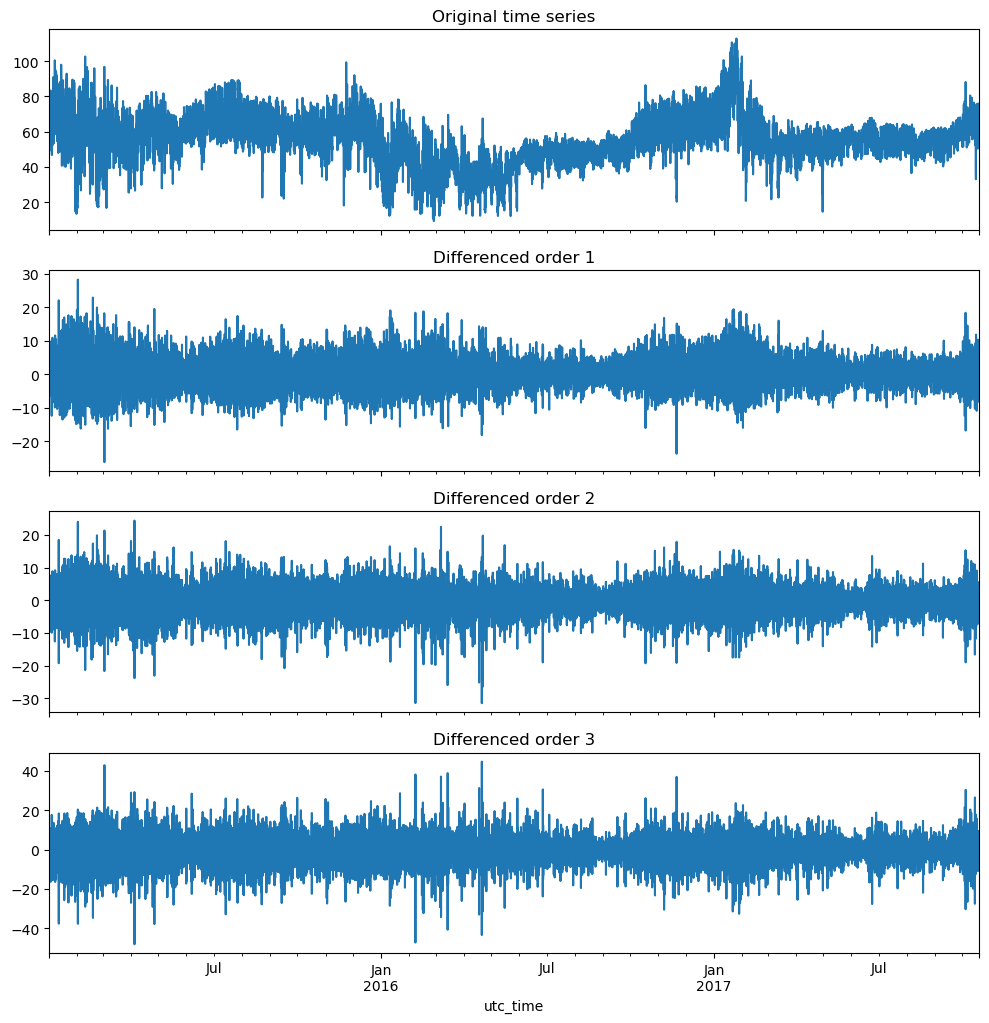

In [72]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 12), sharex=True)
y_train.plot(ax=axs[0], title='Original time series')
y_train_diff.plot(ax=axs[1], title='Differenced order 1')
y_train_diff2.plot(ax=axs[2], title='Differenced order 2');
y_train_diff3.plot(ax=axs[3], title='Differenced order 3');

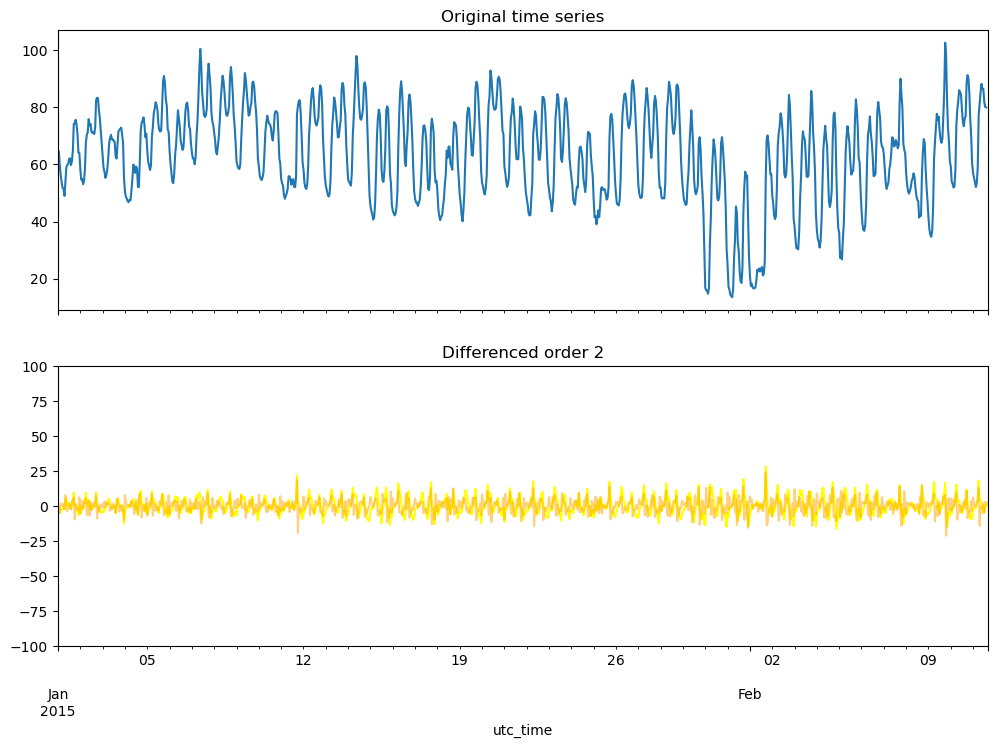

In [73]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
y_train[0:1000].plot(ax=axs[0], title='Original time series')
y_train_diff[0:1000].plot(ax=axs[1], title='Differenced order 1', color='yellow')
y_train_diff2[0:1000].plot(ax=axs[1], title='Differenced order 2', color='orange', alpha=0.5)
#y_train_diff3[0:1000].plot(ax=axs[1], title='Differenced order 3', color='red', alpha=0.5)
axs[1].set_ylim(-100, 100);

In [74]:
# Check ADF and KPSS if there is a seasonal drift that needs differencing (seasonal order 'D')

seasonal_diff = y_train - y_train.shift(12)  # Half day periodicity

seasonal_diff = seasonal_diff.dropna()

inf_count = np.isinf(seasonal_diff).values.ravel().sum()
print("Number of inf values:", inf_count)

nan_count = seasonal_diff.isna().sum().sum()
print("Number of NaN values:", nan_count)

adf_result = adfuller(seasonal_diff)
print('ADF Statistic:', adf_result[0])
print('p-value of ADF:', adf_result[1])

kpss_result = kpss(seasonal_diff)
print('KPSS Statistic:', kpss_result[0])
print('p-value of KPSS:', kpss_result[1])

Number of inf values: 0
Number of NaN values: 0
ADF Statistic: -27.938663467019143
p-value of ADF: 0.0
KPSS Statistic: 0.0032536631122639507
p-value of KPSS: 0.1


/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/2455432037.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(seasonal_diff)


In [88]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build a simple ARIMAX for predicting the energy price
# Based on the KPSS p-value and the figures above, I will apply a 1st order differencing to the ARIMAX model to remove trend.
# Will try without any differencing.
arimax_order = (1, 0, 1)
# ARIMA seasonal (P,D,Q,s), — seasonal AR, seasonal difference, seasonal MA, and s=seasonal period
seasonal_order = (2, 1, 2, 12)   # There is a 12 hour and 24 hour periodicity to the energy price, will try 12 hours.
# model = SARIMAX(y_train, exog=X_train, order=arimax_order, enforce_stationarity=False, enforce_invertibility=False, freq='h')
model = SARIMAX(y_train, exog=X_train, order=arimax_order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False, freq='h')

# Fit the model
arimax_fit = model.fit(disp=False)
print(arimax_fit.summary())

/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                        SARIMAX Results                                        
Dep. Variable:                            price actual   No. Observations:                24544
Model:             SARIMAX(1, 0, 1)x(2, 1, [1, 2], 12)   Log Likelihood              -61663.379
Date:                                 Tue, 12 Aug 2025   AIC                         123432.757
Time:                                         18:26:31   BIC                         123862.411
Sample:                                     12-31-2014   HQIC                        123571.956
                                          - 10-19-2017                                         
Covariance Type:                                   opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
daylight_length_hr          74.2775     22.673

In [89]:
# Output model fit stats to file
direct_out = current_dir + '/output/results/ARIMAX'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/ARIMAX_model_train_fit_results_price_2nd_try.txt'
with open(filename_out, 'w') as f:
    f.write(str(arimax_fit.summary()))

In [90]:
# Predict future price
test_rec = test.copy()

forecast_price = arimax_fit.get_forecast(steps=len(X_test), exog=X_test)
y_pred_test = forecast_price.predicted_mean
conf_int = forecast_price.conf_int(alpha=0.32)  # 1 Sigma confidence interval
y_pred_test.index = X_test.index  # Align index, if needed

test_rec['ARIMAX Prediction Price'] = y_pred_test
test_rec['Forecast Price'] = data.loc[split_idx:, forecast_col].to_numpy(copy=True)

# Create new dataframe to plot the ARIMAX results.
# For plotting full range with NaN for prediction in training range
full_pred2 = np.full(N, np.nan)
full_pred2[split_idx:] = test_rec['ARIMAX Prediction Price']
train_pred2 = np.full(N, np.nan)
train_pred2[:split_idx] = arimax_fit.fittedvalues

# The power load predicted previously used to predict price on.
load_predicted = np.full(N, np.nan)
load_predicted[split_idx:] = full_pred[split_idx:]

plot_df2 = pd.DataFrame({
    'utc_time': data['utc_time'].to_numpy(copy=True),
    'Actual Price': data[target_col].to_numpy(copy=True),
    'ARIMAX Prediction Price': full_pred2,
    'ARIMAX Train Prediction Price': train_pred2,
    'Forecast Price': data[forecast_col].to_numpy(copy=True),
    'Actual Power Load': data['total load actual'],
    'Previous Predicted Power Load': load_predicted
})

plot_df2['ARIMAX Lower Bound'] = np.nan
plot_df2['ARIMAX Upper Bound'] = np.nan
plot_df2.loc[split_idx:, 'ARIMAX Lower Bound'] = conf_int.iloc[:, 0].values
plot_df2.loc[split_idx:, 'ARIMAX Upper Bound'] = conf_int.iloc[:, 1].values

# Add significant cols
for col in feature_cols:
    plot_df2[col] = data[col].to_numpy(copy=True)

In [91]:
p = ML_future_energy_predict(plot_df2, 'utc_time', ['Actual Price', 'ARIMAX Prediction Price', 'ARIMAX Train Prediction Price',
                                                    'Forecast Price', 'Actual Power Load', 'Previous Predicted Power Load'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Price\ (EUR/MWh)\ and\ Power\ Load\ (MWh)}$$",
                             'Energy Price, ARIMAX Prediction Price, Train Prediction Price,'
                             + ' Forecast Price, Power Load, and Predicted Power Load vs UTC Time and Temperature',
                             feature_columns=['temp'],
                             features_ylabel=[r"$$\mathrm{Temperature\ (K)}$$"],
                             p=None, normalize=False, other_colors=False, color_plot=['dorange', 'red', 'black', 'blue', 'violet', 'cyan'],
                             color_features=['green'],
                             labels=['Actual Price', 'ARIMAX Predicted Price', 'ARIMAX Predicted Train Price',
                                     'Forecast Price', 'Actual Power Load', 'Previous Predicted Power Load'],
                             features_labels=['Temperature'], symbols=['star', 'triangle', 'square', 'diamond', 'hex', 'plus'],
                             symbols_features=['circle'], test_pred_col='ARIMAX Prediction Price',
                             lower_conf_col='ARIMAX Lower Bound', upper_conf_col='ARIMAX Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/ARIMAX/plots'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Energy_Price_ARIMAX_2nd_try.html'

title = 'Energy Price, ARIMAX Predicted Price, Forecast Price, Actual Power Load, and Previous Predicted Power Load vs UTC Time and Temperature'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/4162108655.py:29: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/ARIMAX/plots/Predicted_Energy_Price_ARIMAX_2nd_try.html'

In [92]:
p, p_hist = plot_train_test_residuals_bokeh(y_train, arimax_fit, y_test, test_rec['ARIMAX Prediction Price'], test_rec.index,
                                            title="Train/Test Residuals Analysis for Energy Price")

# Save plots.
direct_out = current_dir + '/output/results/ARIMAX/plots'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_train_test_energy_price_2nd_try.html'

title = 'Train/Test Residuals Analysis for Energy Price'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_energy_price_2nd_try.html'

title = 'Histogram of the Residuals for Energy Price'

save(p_hist, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/54431171.py:15: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_80580/54431171.py:21: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p_hist, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/ARIMAX/plots/Histogram_residuals_train_test_energy_price_2nd_try.html'

In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

# --- Full Test Set Metrics ---
metrics = {}

# Full range
y_true_full = y_test.values
y_arimax_full = test_rec['ARIMAX Prediction Price'].values
y_forecast_full = test_rec['Forecast Price'].values

metrics['All Test Data'] = {
    'ARIMAX': {
        "MSE": mean_squared_error(y_true_full, y_arimax_full),
        "RMSE": np.sqrt(mean_squared_error(y_true_full, y_arimax_full)),
        "MAE": mean_absolute_error(y_true_full, y_arimax_full),
        "MAPE": mean_absolute_percentage_error(y_true_full, y_arimax_full),
        "R2": r2_score(y_true_full, y_arimax_full)
    },
    'Forecast': {
        "MSE": mean_squared_error(y_true_full, y_forecast_full),
        "RMSE": np.sqrt(mean_squared_error(y_true_full, y_forecast_full)),
        "MAE": mean_absolute_error(y_true_full, y_forecast_full),
        "MAPE": mean_absolute_percentage_error(y_true_full, y_forecast_full),
        "R2": r2_score(y_true_full, y_forecast_full)
    }
}

# --- First Day Only (first 24 points/24 hours) ---
y_true_day1 = y_test.values[:24]
y_arimax_day1 = test_rec['ARIMAX Prediction Price'].values[:24]
y_forecast_day1 = test_rec['Forecast Price'].values[:24]

metrics['First 24 Hours'] = {
    'ARIMAX': {
        "MSE": mean_squared_error(y_true_day1, y_arimax_day1),
        "RMSE": np.sqrt(mean_squared_error(y_true_day1, y_arimax_day1)),
        "MAE": mean_absolute_error(y_true_day1, y_arimax_day1),
        "MAPE": mean_absolute_percentage_error(y_true_day1, y_arimax_day1),
        "R2": r2_score(y_true_day1, y_arimax_day1)
    },
    'Forecast': {
        "MSE": mean_squared_error(y_true_day1, y_forecast_day1),
        "RMSE": np.sqrt(mean_squared_error(y_true_day1, y_forecast_day1)),
        "MAE": mean_absolute_error(y_true_day1, y_forecast_day1),
        "MAPE": mean_absolute_percentage_error(y_true_day1, y_forecast_day1),
        "R2": r2_score(y_true_day1, y_forecast_day1)
    }
}

# --- Format as a Pretty DataFrame ---
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics.keys()
    for model in metrics[section].keys()
})

# Reorder for readability
df_metrics = df_metrics[[
    ('All Test Data', 'ARIMAX'), ('All Test Data', 'Forecast'),
    ('First 24 Hours', 'ARIMAX'), ('First 24 Hours', 'Forecast')
]]

# Print to console
print(df_metrics.round(3))

# Output to CSV and TXT (tabular)
direct_out = current_dir + '/output/results/ARIMAX'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/arimax_vs_forecast_metrics_energy_price_2nd_try.csv'
df_metrics.to_csv(filename_out)

     All Test Data          First 24 Hours         
            ARIMAX Forecast         ARIMAX Forecast
MSE      14778.402  152.639         14.528   38.767
RMSE       121.566   12.355          3.812    6.226
MAE        103.277    9.194          3.013    6.159
MAPE       183.520   16.094          5.183    9.877
R2         -95.608    0.002          0.731    0.282
